# Financial Data Science Final Assignment - Group 3

# Task 1: NBBO reconstruction and execution quality
**Leonardo Sitzia (13124735)**

**Task 1.1: Local BBOs**

Documentation of the local best prices (BBOs) for all venues per available timestamp and a report of all local best sizes for the respective prices. 

In [ ]:
# Import data handling, plotting and statistics modules
import pandas as pd
import numpy as np
from plotnine import (
    ggplot, aes, geom_step, geom_histogram, geom_vline,
    facet_wrap, coord_cartesian, labs, theme, scale_x_datetime
)
from mizani.formatters import date_format
from scipy.stats.mstats import winsorize

# Load US quotes and trades
DATA_DIR_US = "data/data_US/"

quotes_us = pd.read_csv(DATA_DIR_US + "US2561631068_quotes_incremental.csv")
trades_us = pd.read_csv(DATA_DIR_US + "US2561631068_trades.csv")

# Inspect data structure quotes_us
quotes_us.head(2)

,Unnamed: 0,side,price,size,order_id,event_timestamp,lob_action,old_price,old_size,old_order_id,...,modify_count,end_of_event,best_ask_num_orders,best_bid_num_orders,level_num_orders_total,level_size_total,total_ask_orders,total_bid_orders,market_state,venue
0,0,BID,35.41,1878,1.577249e+16,2023-09-01 08:00:40.339836097,INSERT,NaN,0,NaN,...,0,True,0,1,1,1878,0,1,PRE_OPEN,XASE
1,1,BID,47.25,100,1.577249e+16,2023-09-01 09:20:00.928114164,INSERT,NaN,0,NaN,...,0,True,0,1,1,100,0,2,PRE_OPEN,XASE


In [2]:
# Inspect data structure trades_us
trades_us.head(2)

,Unnamed: 0,trade_id,trade_timestamp,publication_timestamp,aggressor_side,price,execution_size,market_state,sequence_no,currency,printable,bmll_trade_type,trade_action,execution_venue,venue
0,0,6192,2023-09-01 09:33:02.873930097,2023-09-01 13:33:02.873930097,BID,51.31,200,CONTINUOUS_TRADING,0,USD,True,LIT,NEW,XASE,XASE
1,1,34803,2023-09-01 09:47:51.369308176,2023-09-01 13:47:51.369308176,ASK,51.03,2,CONTINUOUS_TRADING,0,USD,True,LIT,NEW,XASE,XASE


In [3]:
# Convert timestamp column (string) into actual timestamp format
quotes_us["event_timestamp"] = pd.to_datetime(quotes_us["event_timestamp"])
quotes_us.dtypes

Unnamed: 0                         int64
side                                 str
price                            float64
size                               int64
order_id                         float64
event_timestamp           datetime64[ns]
lob_action                           str
old_price                        float64
old_size                           int64
old_order_id                     float64
order_executed                      bool
execution_price                  float64
execution_size                     int64
price_level                        int64
old_price_level                    int64
best_ask_price                   float64
best_ask_size                      int64
total_ask_size                     int64
best_bid_price                   float64
best_bid_size                      int64
total_bid_size                     int64
is_new_best_price                   bool
is_new_best_size                    bool
original_order_id                  int64
trade_id        

In [4]:
# Identify the different venues
quotes_us["venue"].unique()

<StringArray>
['XASE', 'XCIS', 'EDGA', 'EDGX', 'XCHI', 'XNYS', 'ARCX', 'XNAS', 'XPSX',
 'BATY', 'BATS']
Length: 11, dtype: str

In [5]:
# Convert timestamp column (string) into actual timestamp format
trades_us["trade_timestamp"] = pd.to_datetime(trades_us["trade_timestamp"])
trades_us.dtypes


Unnamed: 0                        int64
trade_id                          int64
trade_timestamp          datetime64[ns]
publication_timestamp               str
aggressor_side                      str
price                           float64
execution_size                    int64
market_state                        str
sequence_no                       int64
currency                            str
printable                          bool
bmll_trade_type                     str
trade_action                        str
execution_venue                     str
venue                               str
dtype: object

Now that the columns and data types of the US data are analysed, it is necessary to identify which orders set a new best price (is_new_best_price == True) and which orders set a new order size at the best price (is_new_best_size == True) on their venue. By filtering the data this way, only the quotes relevant for a new best price or order size are retained. Additionally, the focus is on continuous trading data, as the goal is to analyse the spreads and prices during normal trading hours. Through these steps, all relevant quotes per venue can be aggregated and the documentation of the local BBOs can begin.

In [6]:
# Filter for continuous trading
print(quotes_us["market_state"].unique())
quotes_ct_us = quotes_us[quotes_us["market_state"] == "CONTINUOUS_TRADING"]

# Filter for local BBO changes (price or size)
mask_us = (
    quotes_ct_us["is_new_best_price"]
    | quotes_ct_us["is_new_best_size"]
)

# Subset quotes dataframe to the boolean mask
bbo_changes_us = quotes_ct_us[mask_us]

<StringArray>
['PRE_OPEN', 'CONTINUOUS_TRADING', 'POST_TRADE', 'CLOSED']
Length: 4, dtype: str


In [7]:
# Check the progress
original = len(quotes_us)
filtered = len(bbo_changes_us)

print("Original:", original)
print("After BBO filter:", filtered)
print(f"Reduction: {(1 - filtered / original) * 100:.2f}%")

Original: 563017
After BBO filter: 308899
Reduction: 45.14%


Filtering for continuous trading data, new best price changes and best size changes leads to a reduction of quotes by 45%. It reduces the US quote data to only those quotes that are necessary to document the local BBOs.

In [8]:
# Check for one-sided BBOs
print("Missing bid:", bbo_changes_us["best_bid_price"].isna().sum())
print("Missing ask:", bbo_changes_us["best_ask_price"].isna().sum())
print("Zero bid size:", (bbo_changes_us["best_bid_size"] == 0).sum())
print("Zero ask size:", (bbo_changes_us["best_ask_size"] == 0).sum())

# Count one-sided BBOs (any condition true)
one_sided_us = (
    bbo_changes_us["best_bid_price"].isna()
    | bbo_changes_us["best_ask_price"].isna()
    | (bbo_changes_us["best_bid_size"] == 0)
    | (bbo_changes_us["best_ask_size"] == 0)
)
print("Total one-sided BBOs:", one_sided_us.sum())

Missing bid: 174
Missing ask: 226
Zero bid size: 174
Zero ask size: 226
Total one-sided BBOs: 389


Following Kaminski, Laschinger, and Riordan (2026), one-sided BBOs are discarded. Extreme spreads are winsorised to mitigate the influence of non-competitive quotes. Winsorisation preserves the sample size by capping extreme values at the threshold, whereas trimming would reduce the number of observations and potentially bias the sample. Extreme spreads stem from non-competitive quotes on smaller venues and do not affect the NBBO, which by construction takes the best prices across venues.

In [101]:
# Remove one-sided BBOs (missing price or zero size)
valid_mask_us = (
    bbo_changes_us["best_bid_price"].notna()
    & bbo_changes_us["best_ask_price"].notna()
    & (bbo_changes_us["best_bid_size"] > 0)
    & (bbo_changes_us["best_ask_size"] > 0)
)

bbo_clean_us = bbo_changes_us[valid_mask_us].copy()

print(
    "Removed:",
    len(bbo_changes_us) - len(bbo_clean_us),
    "one-sided BBOs"
)

Removed: 389 one-sided BBOs


In [10]:
# Compute local spread
bbo_clean_us["spread"] = (
    bbo_clean_us["best_ask_price"] - bbo_clean_us["best_bid_price"]
)

# Check spread distribution before winsorisation
print(bbo_clean_us["spread"].describe().round(4))
print("Negative spreads:", (bbo_clean_us["spread"] < 0).sum())

count    308510.0000
mean          0.3734
std           1.1647
min           0.0100
25%           0.0200
50%           0.0500
75%           0.1300
max           6.9300
Name: spread, dtype: float64
Negative spreads: 0


In [11]:
# Test percentiles for winsorisation of the US quote data
for p in [0.90, 0.95, 0.97, 0.99]:
    print(
        f"{p:.0%}: ${bbo_clean_us['spread'].quantile(p):.2f}"
        )

90%: $0.28
95%: $3.31
97%: $3.71
99%: $6.92


The jump from $0.28 at the 90th percentile to $3.31 at the 95th percentile marks the transition from competitive to non-competitive quotes. Following Kaminski et al. (2026), the spread is winsorised at the upper 5% level (95th percentile), capping systematically wide spreads from venues such as XASE and XPSX without distorting the competitive venues. This conservative threshold caps only the most extreme, clearly non-competitive spreads while preserving moderately wide but potentially legitimate quotes. Winsorising the spreads ensures that the reported means are not distorted by a small number of extreme non-competitive quotes. The underlying bid and ask prices remain unchanged, so the NBBO reconstruction is unaffected.

In [12]:
# Winsorize spread at the upper 5% level
bbo_win_us = bbo_clean_us.copy()
bbo_win_us["spread"] = winsorize(bbo_win_us["spread"], limits=(0, 0.05))

print(bbo_win_us["spread"].describe().round(4))

count    308510.0000
mean          0.2951
std           0.8021
min           0.0100
25%           0.0200
50%           0.0500
75%           0.1300
max           3.3100
Name: spread, dtype: float64


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:4786: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.


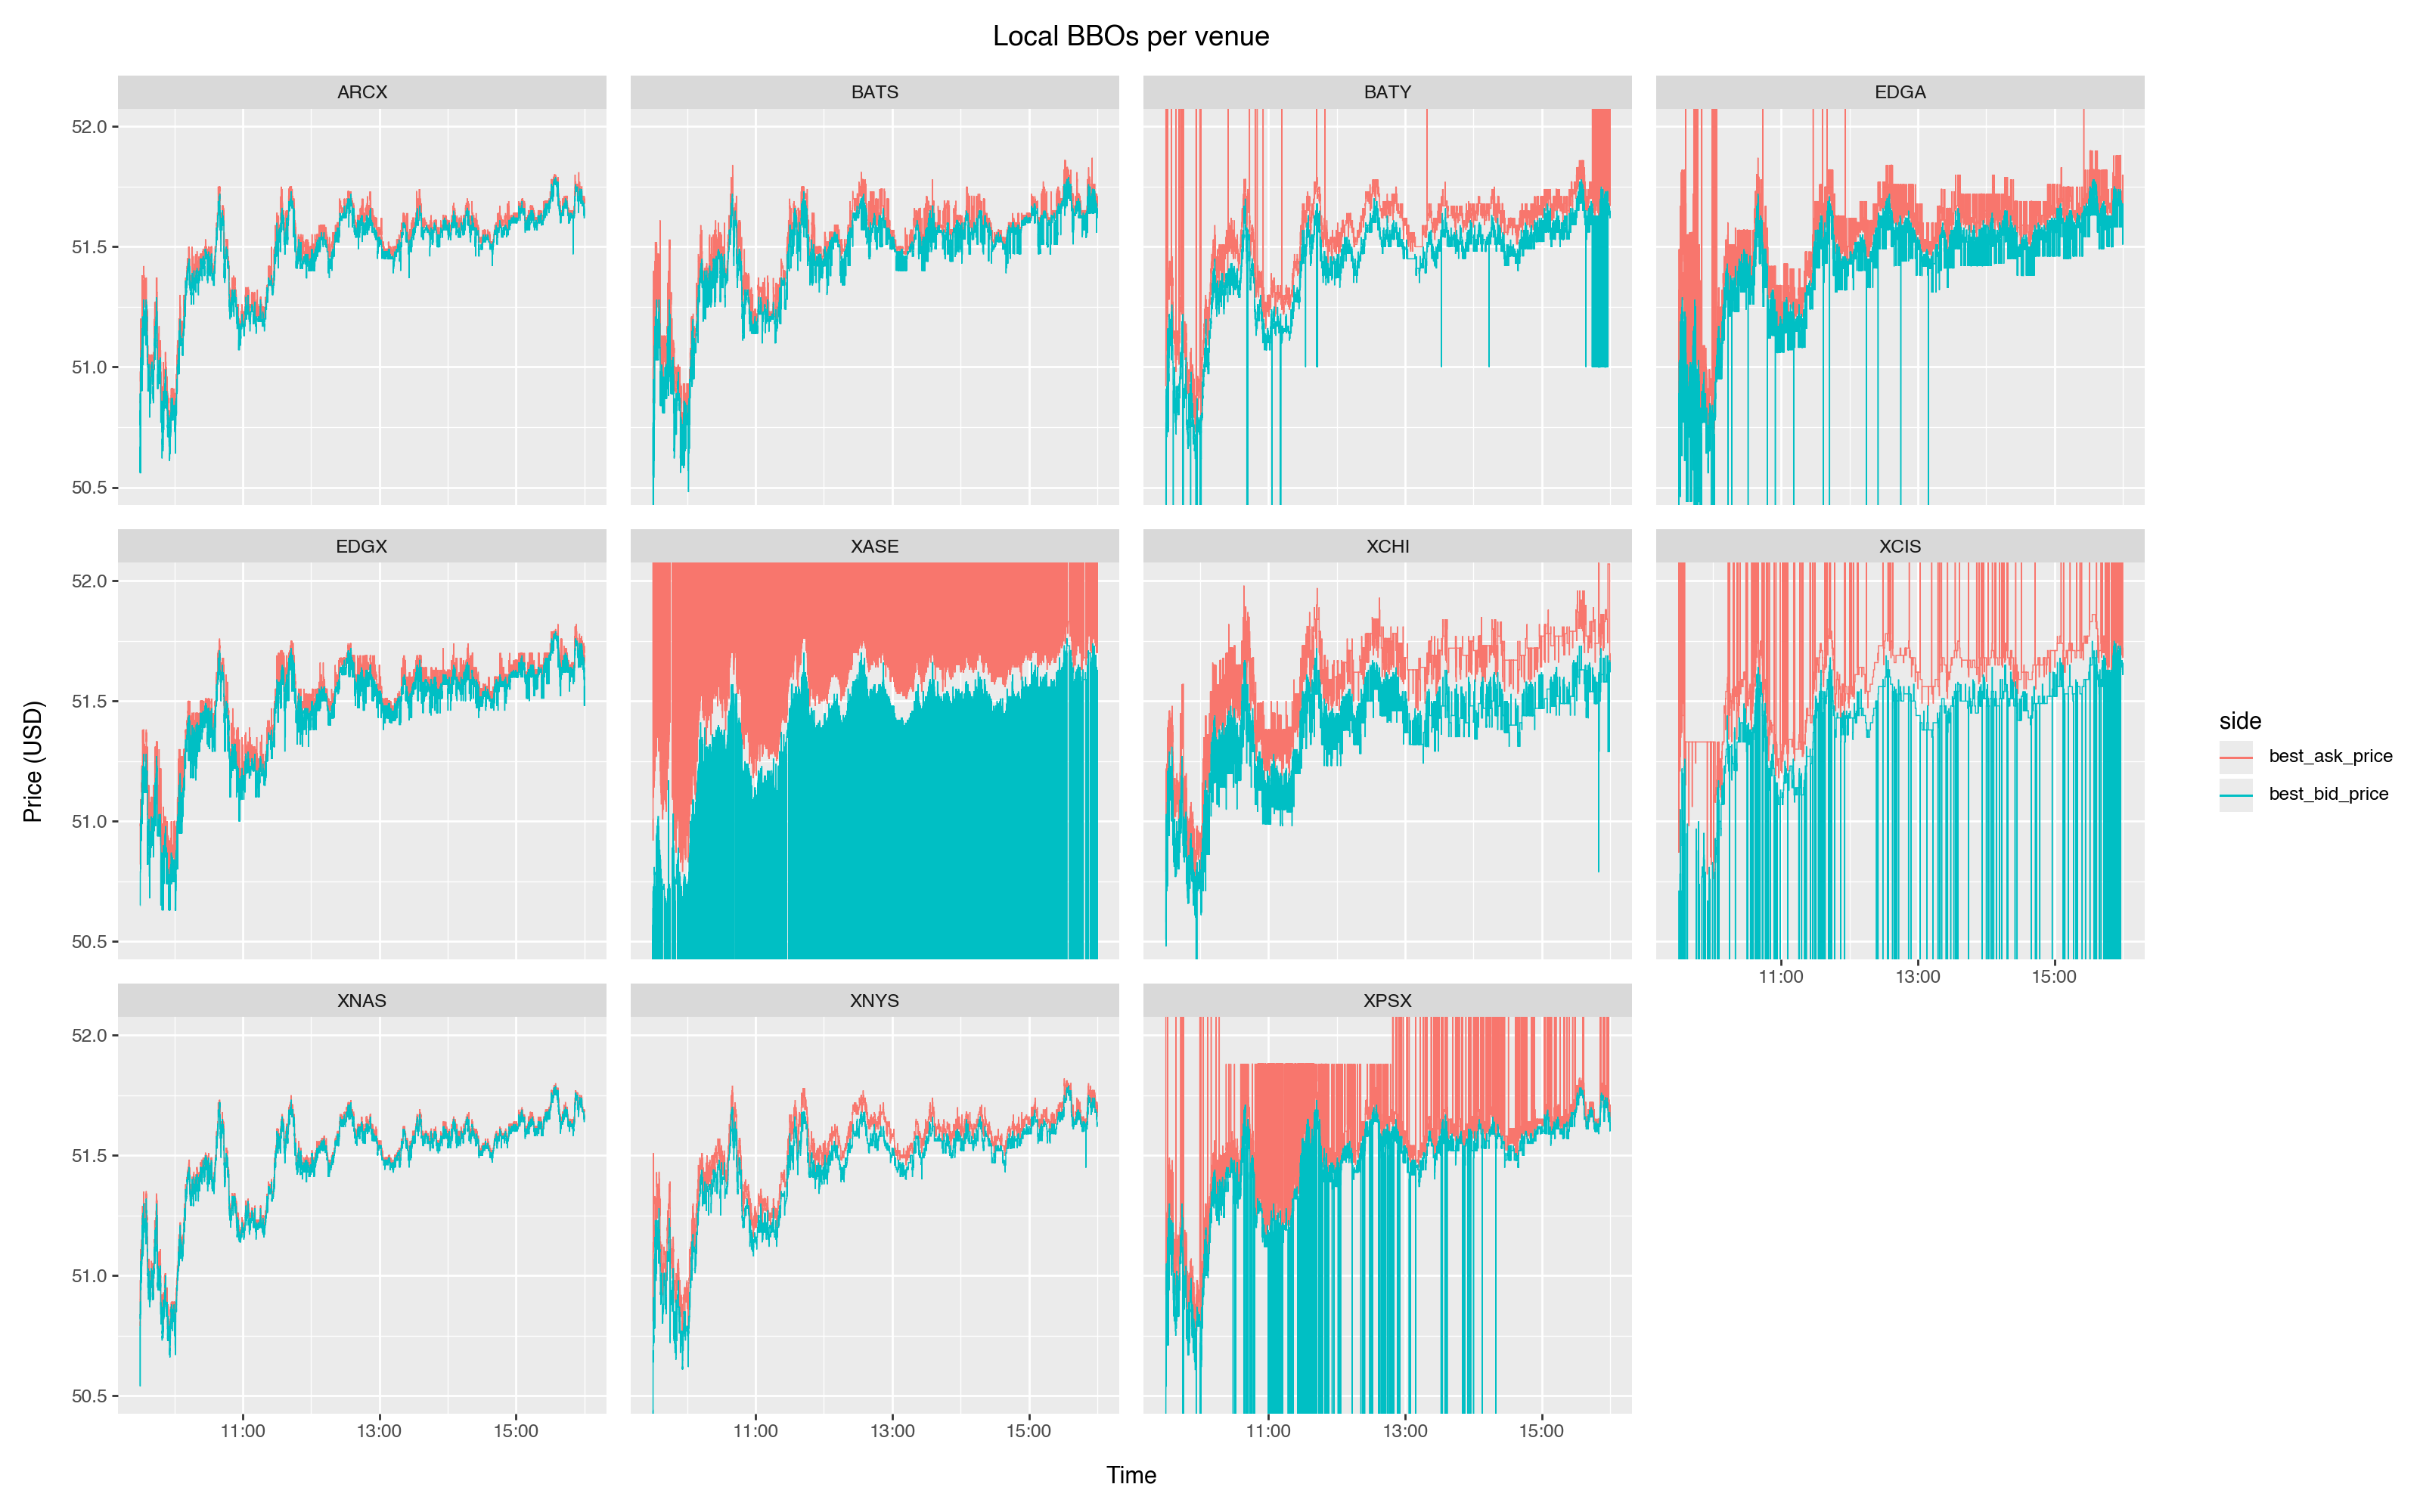

In [13]:
# Select relevant columns for BBO plot
bbo_plot_win_us = bbo_win_us[[
    "event_timestamp", "venue",
    "best_bid_price", "best_ask_price"
]].copy()

# Reshape from wide to long format for plotting
bbo_long_win_us = bbo_plot_win_us.melt(
    id_vars=["event_timestamp", "venue"],
    value_vars=["best_bid_price", "best_ask_price"],
    var_name="side",
    value_name="price"
)

# Plot local BBOs per venue
(ggplot(bbo_long_win_us, aes(x="event_timestamp", y="price", color="side"))
 + geom_step(size=0.3)
 + facet_wrap("venue", scales="fixed")
 + coord_cartesian(ylim=(50.5, 52))
 + labs(x="Time", y="Price (USD)",
        title="Local BBOs per venue")
 + theme(figure_size=(16, 10))
 + scale_x_datetime(labels=date_format("%H:%M"))
 )

In [14]:
bbo_clean_us.groupby("venue")["spread"].describe().round(4)

,count,mean,std,min,25%,50%,75%,max
venue,,,,,,,,
ARCX,26638.0,0.0434,0.0339,0.01,0.02,0.04,0.05,0.44
BATS,24449.0,0.0736,0.0728,0.01,0.02,0.05,0.10,0.78
BATY,17142.0,0.1738,0.2653,0.01,0.11,0.14,0.16,4.29
EDGA,20709.0,0.1512,0.2436,0.01,0.07,0.10,0.16,3.38
EDGX,52953.0,0.0460,0.0361,0.01,0.02,0.03,0.06,0.40
XASE,27721.0,3.1689,2.4126,0.02,0.19,3.37,3.80,6.93
XCHI,24475.0,0.2070,0.0873,0.02,0.14,0.19,0.26,1.78
XCIS,2751.0,0.7104,1.2624,0.01,0.12,0.18,0.25,5.76
XNAS,80397.0,0.0246,0.0162,0.01,0.01,0.02,0.03,0.26


Venues such as XNAS, EDGX, and ARCX display consistently tight spreads throughout the trading day. XASE quotes persistently wide spreads (median ≈ $3.37), reflecting non-competitive quoting, while BATY, XCIS, and XPSX are mostly tight but show occasional spread spikes (up to $5.76). Prices trend upward over the day from approximately $50.70 to over $51.50.

In [15]:
bbo_win_us.groupby("venue")["spread"].describe().round(4)

,count,mean,std,min,25%,50%,75%,max
venue,,,,,,,,
ARCX,26638.0,0.0434,0.0339,0.01,0.02,0.04,0.05,0.44
BATS,24449.0,0.0736,0.0728,0.01,0.02,0.05,0.10,0.78
BATY,17142.0,0.1730,0.2549,0.01,0.11,0.14,0.16,3.31
EDGA,20709.0,0.1512,0.2436,0.01,0.07,0.10,0.16,3.31
EDGX,52953.0,0.0460,0.0361,0.01,0.02,0.03,0.06,0.40
XASE,27721.0,2.3057,1.4497,0.02,0.19,3.31,3.31,3.31
XCHI,24475.0,0.2070,0.0873,0.02,0.14,0.19,0.26,1.78
XCIS,2751.0,0.6415,1.0318,0.01,0.12,0.18,0.25,3.31
XNAS,80397.0,0.0246,0.0162,0.01,0.01,0.02,0.03,0.26


After winsorisation, all spreads above the 95th-percentile threshold ($3.31) are capped, which affects BATY, EDGA, XASE, XCIS and XPSX. The effect is largest for XASE, whose mean drops from 3.17 to 2.31, since most of its spreads lie above the threshold. This shows the importance of cleaning the data for reliable descriptive statistics, especially mean values. The data is not cleaned any further, as the remaining wide quotes could be legitimate but non-competitive and do not affect the NBBO, which by construction takes the best price across venues.

In [16]:
# Report local best sizes per venue
size_stats_us = bbo_win_us.groupby("venue")[
    ["best_bid_size", "best_ask_size"]
].agg(["mean", "median", "min", "max"]).round(2)

size_stats_us

best_bid_size                  best_ask_size                  
               mean median min   max          mean median min    max
venue                                                               
ARCX          86.05   65.0   1  1397         83.15   66.0   1   2500
BATS          97.13   70.0   1  1200         99.52  100.0   1   2400
BATY         391.92  400.0   1  2500        385.51  400.0   1   3800
EDGA          97.87  100.0   1   400         99.67  100.0   1    300
EDGX         135.06  100.0   1  2501        119.28  100.0   1   5000
XASE         238.22  100.0   1  2200        235.08  163.0   1   2900
XCHI         308.56  200.0   6  1200        298.54  200.0   1   1200
XCIS         103.23  100.0   1   500        103.04  100.0   1    500
XNAS         167.27  100.0   1  5500        246.72  111.0   1  11662
XNYS          64.87   63.0   1   300         78.59   64.0   1    400
XPSX         212.29   63.0   1  2981        380.55  300.0   1   4900

The results show that displayed depth and spread tightness represent two distinct dimensions of liquidity. XNYS shows low median depth (~63 shares) yet maintains relatively tight spreads, while BATY posts the highest median depth (400 shares) but quotes wider spreads. This indicates that venues compete along different dimensions. Some exchanges prioritize price competition (tight spreads, small size), others quantity (large size, wider spreads). XNAS, the primary listing exchange for DocuSign (NASDAQ: DOCU, ISIN US2561631068), combines tight spreads with substantial depth (up to 11,662 shares).

In [17]:
# Report local best prices and sizes per venue for every available timestamp
bbo_us = bbo_win_us[[
    "event_timestamp", "venue",
    "best_bid_price", "best_bid_size",
    "best_ask_price", "best_ask_size"
]].copy()

bbo_us

,event_timestamp,venue,best_bid_price,best_bid_size,best_ask_price,best_ask_size
25,2023-09-01 09:30:00.083961314,XASE,50.44,200,51.01,100
27,2023-09-01 09:30:00.713562640,XASE,50.51,1400,51.01,100
28,2023-09-01 09:30:00.713586081,XASE,50.51,1400,50.97,1400
29,2023-09-01 09:30:00.904972282,XASE,50.44,200,50.97,1400
30,2023-09-01 09:30:00.904976493,XASE,50.44,200,51.01,100
...,...,...,...,...,...,...
562955,2023-09-01 15:59:58.042029000,BATS,51.66,50,51.70,300
562956,2023-09-01 15:59:58.042079000,BATS,51.66,50,51.70,100
562957,2023-09-01 15:59:58.042347000,BATS,51.66,150,51.70,100
562958,2023-09-01 15:59:58.190377000,BATS,51.66,100,51.70,100


The result shows all best bids/asks prices and corresponding sizes at every timestamp for their respective venue. This is the basis for constructing the NBBO in Task 1.2.

**Task 1.2: NBBO Reconstruction**

Reconstruction of the global best prices (NBBO) consolidated over all US venues. The NBBO reports the consolidated depth at the NBBO, number of venues quoting at the NBBO and the per venue distance to the current NBBO.

In [18]:
# Pivot to get one column per venue (long to wide), forward-fill gaps
bid_wide_us = bbo_us.pivot_table(
    index="event_timestamp", columns="venue",
    values="best_bid_price", aggfunc="last"
).ffill()

ask_wide_us = bbo_us.pivot_table(
    index="event_timestamp", columns="venue",
    values="best_ask_price", aggfunc="last"
).ffill()

# Compute NBBO
nbbo_us = pd.DataFrame(index=bid_wide_us.index)
nbbo_us["nbbo_bid"] = bid_wide_us.max(axis=1)
nbbo_us["nbbo_ask"] = ask_wide_us.min(axis=1)
nbbo_us["nbbo_spread"] = nbbo_us["nbbo_ask"] - nbbo_us["nbbo_bid"]

print("Negative NBBO spreads:", (nbbo_us["nbbo_spread"] < 0).sum())
print("Zero spreads (locked):", (nbbo_us["nbbo_spread"] == 0).sum())
print(nbbo_us["nbbo_spread"].describe().round(4))

print(bid_wide_us.head(10))
print(ask_wide_us.head(10))

Negative NBBO spreads: 19
Zero spreads (locked): 6367
count    301620.0000
mean          0.0203
std           0.0142
min          -0.0200
25%           0.0100
50%           0.0200
75%           0.0200
max           0.1600
Name: nbbo_spread, dtype: float64
venue                           ARCX   BATS  BATY  EDGA   EDGX  XASE  XCHI  \
event_timestamp                                                              
2023-09-01 09:30:00.001056507    NaN    NaN   NaN   NaN    NaN   NaN   NaN   
2023-09-01 09:30:00.004293043    NaN    NaN   NaN   NaN    NaN   NaN   NaN   
2023-09-01 09:30:00.005554447    NaN    NaN   NaN   NaN    NaN   NaN   NaN   
2023-09-01 09:30:00.009175000    NaN  50.36   NaN   NaN    NaN   NaN   NaN   
2023-09-01 09:30:00.014328435    NaN  50.36   NaN   NaN    NaN   NaN   NaN   
2023-09-01 09:30:00.041103000    NaN  50.36   NaN   NaN  50.65   NaN   NaN   
2023-09-01 09:30:00.045781330    NaN  50.36   NaN   NaN  50.65   NaN   NaN   
2023-09-01 09:30:00.045816057    NaN  50.3

In [19]:
# Pivot sizes the same way
bid_size_wide_us = bbo_us.pivot_table(
    index="event_timestamp", columns="venue",
    values="best_bid_size", aggfunc="last"
).ffill()

ask_size_wide_us = bbo_us.pivot_table(
    index="event_timestamp", columns="venue",
    values="best_ask_size", aggfunc="last"
).ffill()

# Consolidated depth: sum of sizes where venue price == NBBO price
nbbo_us["depth_bid"] = bid_size_wide_us[
    bid_wide_us.eq(nbbo_us["nbbo_bid"], axis=0)
].sum(axis=1)

nbbo_us["depth_ask"] = ask_size_wide_us[
    ask_wide_us.eq(nbbo_us["nbbo_ask"], axis=0)
].sum(axis=1)

nbbo_us["venues_at_bid"] = (
    bid_wide_us.eq(nbbo_us["nbbo_bid"], axis=0).sum(axis=1)
)
nbbo_us["venues_at_ask"] = (
    ask_wide_us.eq(nbbo_us["nbbo_ask"], axis=0).sum(axis=1)
)

cols = ["depth_bid", "depth_ask", "venues_at_bid", "venues_at_ask"]
print(nbbo_us[cols].describe().round(2))

       depth_bid  depth_ask  venues_at_bid  venues_at_ask
count  301620.00  301620.00      301620.00      301620.00
mean      264.43     312.11           2.45           2.34
std       370.25     566.87           1.43           1.34
min         1.00       1.00           1.00           1.00
25%        95.00      70.00           1.00           1.00
50%       174.00     200.00           2.00           2.00
75%       317.00     362.00           3.00           3.00
max      5800.00   12251.00           9.00           9.00


At the NBBO, consolidated depth averages 264 shares on the bid and 312 on the ask (median 174 and 200), with a median of two venues quoting at each side. Because more than one venue is usually at the best price, the consolidated depth aggregates the displayed size of several venues rather than relying on a single feed. This result illustrates the economic point of consolidation, as the market depth at the consolidated best price is usually greater than on most venues individually.

In [21]:
# Identify which venues quote at the NBBO bid
venues_at_nbbo_bid_us = bid_wide_us.eq(nbbo_us["nbbo_bid"], axis=0)
venues_at_nbbo_ask_us = ask_wide_us.eq(nbbo_us["nbbo_ask"], axis=0)

# Check venues at NBBO for first 10 timestamps (compare with bid_wide_us)
print(venues_at_nbbo_bid_us.head(10))

venue                           ARCX   BATS   BATY   EDGA   EDGX   XASE  \
event_timestamp                                                           
2023-09-01 09:30:00.001056507  False  False  False  False  False  False   
2023-09-01 09:30:00.004293043  False  False  False  False  False  False   
2023-09-01 09:30:00.005554447  False  False  False  False  False  False   
2023-09-01 09:30:00.009175000  False  False  False  False  False  False   
2023-09-01 09:30:00.014328435  False  False  False  False  False  False   
2023-09-01 09:30:00.041103000  False  False  False  False  False  False   
2023-09-01 09:30:00.045781330  False  False  False  False  False  False   
2023-09-01 09:30:00.045816057  False  False  False  False  False  False   
2023-09-01 09:30:00.045849085  False  False  False  False  False  False   
2023-09-01 09:30:00.056226718  False  False  False  False  False  False   

venue                           XCHI   XCIS  XNAS   XNYS   XPSX  
event_timestamp                  

In [22]:
# Share of time each venue quotes at the NBBO bid/ask
pct_at_nbbo_bid_us = venues_at_nbbo_bid_us.mean() * 100
pct_at_nbbo_ask_us = venues_at_nbbo_ask_us.mean() * 100

print("% of time at NBBO bid:")
print(pct_at_nbbo_bid_us.sort_values(ascending=False).round(2))
print("\n% of time at NBBO ask:")
print(pct_at_nbbo_ask_us.sort_values(ascending=False).round(2))

% of time at NBBO bid:
venue
XNAS    82.46
EDGX    39.16
ARCX    36.79
BATS    34.91
XPSX    19.48
XNYS    15.40
EDGA     9.34
XCHI     2.60
XCIS     2.08
BATY     1.63
XASE     1.20
dtype: float64

% of time at NBBO ask:
venue
XNAS    84.37
ARCX    44.14
EDGX    40.68
BATS    33.83
XPSX     9.57
EDGA     8.35
XNYS     7.46
BATY     2.23
XCHI     1.69
XCIS     0.73
XASE     0.68
dtype: float64


In [20]:
# Per-venue distance to NBBO (positive = worse than NBBO)
bid_distance_us = nbbo_us["nbbo_bid"] - bid_wide_us.T  # NBBO_bid - venue_bid
ask_distance_us = ask_wide_us.T - nbbo_us["nbbo_ask"]  # venue_ask - NBBO_ask

In [23]:
# Average distance per venue to NBBO
print("Bid distance to NBBO (positive = worse):")
print(bid_distance_us.mean(axis=1).sort_values().round(4))
print("\nAsk distance to NBBO (positive = worse):")
print(ask_distance_us.mean(axis=1).sort_values().round(4))

Bid distance to NBBO (positive = worse):
venue
XNAS    0.0022
ARCX    0.0147
EDGX    0.0147
XNYS    0.0285
BATS    0.0289
BATY    0.0697
EDGA    0.0823
XCHI    0.1156
XPSX    0.1444
XCIS    0.4042
XASE    2.3515
dtype: float64

Ask distance to NBBO (positive = worse):
venue
XNAS    0.0018
EDGX    0.0122
ARCX    0.0135
BATS    0.0258
XNYS    0.0343
BATY    0.0735
EDGA    0.0746
XPSX    0.1080
XCHI    0.1168
XCIS    0.2093
XASE    2.1912
dtype: float64


The per-venue distance to the NBBO mirrors the competitiveness ranking. XNAS sits almost exactly at the NBBO (≈ $0.002 on both sides), whereas XASE is farthest away (≈ $2.35 on the bid). The measure is event-weighted over forward-filled quotes, so for low-activity venues it partly reflects quote staleness rather than active non-competitive quoting. A venue's last quote is carried forward while the NBBO moves away (e.g. XASE). The NBBO itself is unaffected, as it always takes the best price across venues. The distance is therefore read together with each venue's share of time at the NBBO.

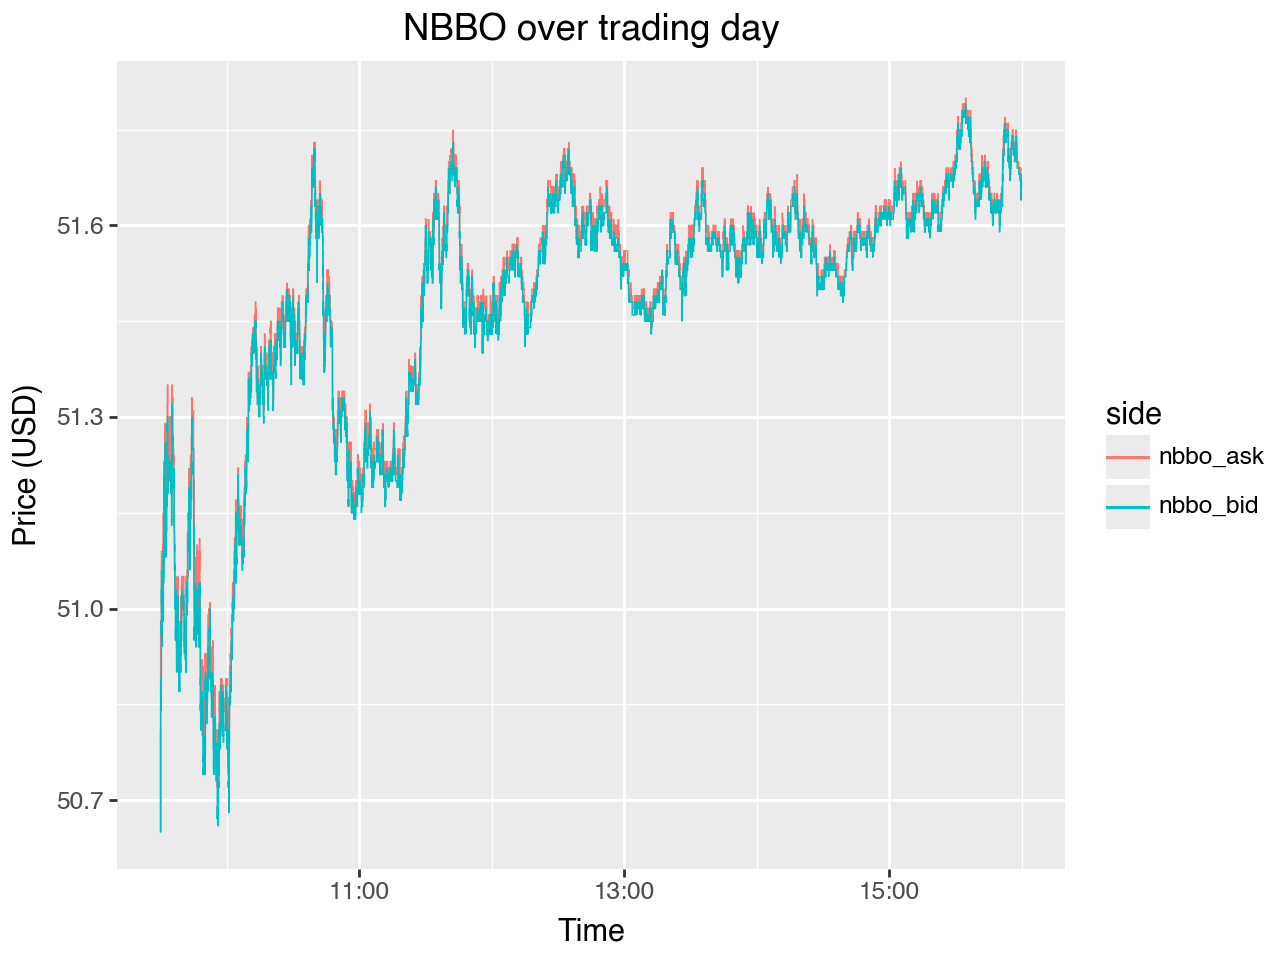

In [24]:
# Plot NBBO
nbbo_plot_us = nbbo_us[["nbbo_bid", "nbbo_ask"]].reset_index().melt(
    id_vars="event_timestamp", var_name="side", value_name="price"
)

(ggplot(nbbo_plot_us, aes(x="event_timestamp", y="price", color="side"))
 + geom_step(size=0.3)
 + labs(x="Time", y="Price (USD)", title="NBBO over trading day")
 + scale_x_datetime(labels=date_format("%H:%M"))
 )

The NBBO spread (mean $0.02) is substantially tighter than local venue spreads (mean $0.30 after winsorisation), confirming that consolidation across venues improves displayed liquidity. XNAS quotes at the NBBO over 80% of the time on both sides. A second tier of venues (ARCX, EDGX, BATS) competes at the NBBO over 30% of the time, while some venues such as XASE, BATY, XCHI and XCIS rarely quote at the best prices (<3%). The data shows 19 crossed markets and 6,367 locked markets, indicating brief episodes of quote asynchrony across venues. These transient states arise because venues update their quotes at slightly different times. A crossed market (negative NBBO spread) occurs when one venue's stale bid temporarily exceeds another venue's updated ask before the quotes resynchronise. With only 19 crossed markets, such states are rare in the US market, consistent with the co-location of US venues in New Jersey.

**Task 1.3: Price Setting Mechanics**

Illustration of price setting mechanics across venues and calculation of adjustment times.

In [25]:
# Detect NBBO bid changes
nbbo_us["bid_changed"] = nbbo_us["nbbo_bid"] != nbbo_us["nbbo_bid"].shift(1)
nbbo_us["ask_changed"] = nbbo_us["nbbo_ask"] != nbbo_us["nbbo_ask"].shift(1)

print("NBBO bid changes:", nbbo_us["bid_changed"].sum())
print("NBBO ask changes:", nbbo_us["ask_changed"].sum())

NBBO bid changes: 11323
NBBO ask changes: 9893


In [26]:
# For each NBBO bid change, find which venues quote the new best bid
nbbo_bid_changes_us = nbbo_us[nbbo_us["bid_changed"]].copy()

# At each change, check which venues match the new NBBO bid
setter_bid_us = bid_wide_us.loc[nbbo_bid_changes_us.index].eq(
    nbbo_bid_changes_us["nbbo_bid"], axis=0
)

# Count how often each venue is the price setter
setter_pct = (
    setter_bid_us.sum() / setter_bid_us.sum().sum() * 100
)
print("Price setter frequency in % (bid):")
print(setter_pct.sort_values(ascending=False).round(2))

Price setter frequency in % (bid):
venue
XNAS    43.69
EDGX    18.57
ARCX    11.62
BATS    11.14
XPSX     5.82
XNYS     4.85
EDGA     2.23
XCHI     0.82
XCIS     0.69
BATY     0.36
XASE     0.22
dtype: float64


In [27]:
# Price setter frequency (ask)
nbbo_ask_changes_us = nbbo_us[nbbo_us["ask_changed"]].copy()
setter_ask_us = ask_wide_us.loc[nbbo_ask_changes_us.index].eq(
    nbbo_ask_changes_us["nbbo_ask"], axis=0
)
setter_ask_pct = (
    setter_ask_us.sum() / setter_ask_us.sum().sum() * 100
)
print("Price setter frequency in % (ask):")
print(setter_ask_pct.sort_values(ascending=False).round(2))

Price setter frequency in % (ask):
venue
XNAS    44.11
EDGX    20.48
ARCX    15.03
BATS    11.89
XPSX     2.79
XNYS     2.34
EDGA     1.77
BATY     0.67
XCHI     0.50
XCIS     0.22
XASE     0.19
dtype: float64


In [28]:
# Compute adjustment time per venue for bid changes
adj_times_bid_us = {}

for venue in bid_wide_us.columns:
    times = []
    for ts in nbbo_bid_changes_us.index:
        new_bid = nbbo_bid_changes_us.loc[ts, "nbbo_bid"]
        # Skip if venue already at new NBBO
        if bid_wide_us.loc[ts, venue] == new_bid:
            continue
        # Find next time this venue matches the new NBBO bid
        future = bid_wide_us.loc[ts:, venue]
        match = future[future == new_bid]
        if len(match) > 0:
            delta = (match.index[0] - ts).total_seconds()
            times.append(delta)
    adj_times_bid_us[venue] = np.mean(times) if times else np.nan

print("Mean adjustment time to NBBO bid (s):")
print(pd.Series(adj_times_bid_us).round(2).sort_values())

Mean adjustment time to NBBO bid (s):
XNAS      34.89
EDGX      82.09
ARCX     121.23
BATS     182.61
XPSX     248.39
EDGA     258.58
XNYS     451.12
BATY     552.03
XCHI     627.36
XASE    1006.69
XCIS    1664.05
dtype: float64


In [29]:
# Compute adjustment time per venue for ask changes
adj_times_ask_us = {}

for venue in ask_wide_us.columns:
    times = []
    for ts in nbbo_ask_changes_us.index:
        new_ask = nbbo_ask_changes_us.loc[ts, "nbbo_ask"]
        if ask_wide_us.loc[ts, venue] == new_ask:
            continue
        future = ask_wide_us.loc[ts:, venue]
        match = future[future == new_ask]
        if len(match) > 0:
            delta = (match.index[0] - ts).total_seconds()
            times.append(delta)
    adj_times_ask_us[venue] = np.mean(times) if times else np.nan

print("Mean adjustment time to NBBO ask (seconds):")
print(pd.Series(adj_times_ask_us).sort_values().round(2))

Mean adjustment time to NBBO ask (seconds):
XNAS      25.00
EDGX      59.88
ARCX      79.79
BATS     160.33
XPSX     183.89
EDGA     211.02
XNYS     269.09
BATY     357.83
XCHI     469.52
XASE     599.98
XCIS    1264.41
dtype: float64


XNAS accounts for 43.7% of setter instances at the NBB and 44.1% at the NBO, showing a dominant role in price discovery. Its mean adjustment time is the fastest across all venues (34.9s bid, 25.0s ask). EDGX and ARCX follow as secondary price setters with adjustment times under 122 seconds. Venues such as XASE (1,006.7s bid) and XCIS (1,664.1s bid) rarely compete at the NBBO and adjust significantly slower, reflecting their limited role in price formation for this security. These venues quote less frequently and in consequence show much longer adjustment times. These findings are consistent with the empirical research showing that the listing (home) market accounts for the preponderance of price discovery for its securities (Hasbrouck, 1995).

**Task 1.4: Lee-Ready Classification**

Identification and comparison of the aggressor side of each trade through the Lee and Ready (1991) algorithm with the dataset labels.

In [30]:
# Match each trade to prevailing NBBO using merge_asof
trades_ct_us = trades_us[
    trades_us["market_state"] == "CONTINUOUS_TRADING"
].copy()
trades_ct_us = trades_ct_us.sort_values("trade_timestamp")

trades_matched_us = pd.merge_asof(
    trades_ct_us,
    nbbo_us[["nbbo_bid", "nbbo_ask"]].reset_index(),
    left_on="trade_timestamp",
    right_on="event_timestamp",
    direction="backward"
)

# Compute midpoint
trades_matched_us["midpoint"] = (
    trades_matched_us["nbbo_bid"] + trades_matched_us["nbbo_ask"]
) / 2

trades_matched_us.head(10)

,Unnamed: 0,trade_id,trade_timestamp,publication_timestamp,aggressor_side,price,execution_size,market_state,sequence_no,currency,printable,bmll_trade_type,trade_action,execution_venue,venue,event_timestamp,nbbo_bid,nbbo_ask,midpoint
0,31,260555,2023-09-01 09:30:00.001056507,2023-09-01 13:30:00.001056507,ASK,50.79,1072,CONTINUOUS_TRADING,0,USD,True,LIT,NEW,XNAS,XNAS,2023-09-01 09:30:00.001056507,50.79,50.81,50.800
1,32,260804,2023-09-01 09:30:00.004293043,2023-09-01 13:30:00.004293043,ASK,50.79,308,CONTINUOUS_TRADING,0,USD,True,LIT,NEW,XNAS,XNAS,2023-09-01 09:30:00.004293043,50.79,50.81,50.800
2,33,260954,2023-09-01 09:30:00.005554447,2023-09-01 13:30:00.005554447,ASK,50.79,1,CONTINUOUS_TRADING,0,USD,True,LIT,NEW,XNAS,XNAS,2023-09-01 09:30:00.005554447,50.79,50.81,50.800
3,34,263786,2023-09-01 09:30:00.045781330,2023-09-01 13:30:00.045781330,ASK,50.79,16,CONTINUOUS_TRADING,0,USD,True,LIT,NEW,XNAS,XNAS,2023-09-01 09:30:00.045781330,50.79,50.80,50.795
4,35,263788,2023-09-01 09:30:00.045816057,2023-09-01 13:30:00.045816057,ASK,50.79,17,CONTINUOUS_TRADING,0,USD,True,LIT,NEW,XNAS,XNAS,2023-09-01 09:30:00.045816057,50.79,50.80,50.795
5,36,263789,2023-09-01 09:30:00.045849085,2023-09-01 13:30:00.045849085,ASK,50.79,16,CONTINUOUS_TRADING,0,USD,True,LIT,NEW,XNAS,XNAS,2023-09-01 09:30:00.045849085,50.79,50.80,50.795
6,37,264757,2023-09-01 09:30:00.065325958,2023-09-01 13:30:00.065325958,ASK,50.79,1554,CONTINUOUS_TRADING,0,USD,True,LIT,NEW,XNAS,XNAS,2023-09-01 09:30:00.065325958,50.74,50.80,50.770
7,39,409877,2023-09-01 09:30:01.068708292,2023-09-01 13:30:01.068708292,ASK,50.69,4,CONTINUOUS_TRADING,0,USD,True,LIT,NEW,XNAS,XNAS,2023-09-01 09:30:01.068708292,50.69,50.80,50.745
8,41,551578,2023-09-01 09:30:01.821433174,2023-09-01 13:30:01.821433174,UNKNOWN,50.72,5,CONTINUOUS_TRADING,0,USD,True,DARK,NEW,XNAS,XNAS,2023-09-01 09:30:01.797638227,50.65,50.79,50.720
9,42,551758,2023-09-01 09:30:01.855772766,2023-09-01 13:30:01.855772766,UNKNOWN,50.72,5,CONTINUOUS_TRADING,0,USD,True,DARK,NEW,XNAS,XNAS,2023-09-01 09:30:01.855705693,50.72,50.80,50.760


In [31]:
# Lee-Ready: Quote Test
trades_matched_us["lr_side"] = np.where(
    trades_matched_us["price"] > trades_matched_us["midpoint"], "BUY",
    np.where(
        trades_matched_us["price"] < trades_matched_us["midpoint"], "SELL",
        None  # exactly at midpoint → tick test needed
    )
)

# Tick Test for trades at the midpoint
trades_matched_us["price_change"] = trades_matched_us["price"].diff()
trades_matched_us["tick_direction"] = trades_matched_us[
    "price_change"
].apply(lambda x: "BUY" if x > 0 else ("SELL" if x < 0 else None))
trades_matched_us["tick_direction"] = (
    trades_matched_us["tick_direction"].ffill()
)

# Fill midpoint trades with tick test
at_midpoint_us = trades_matched_us["lr_side"].isna()
trades_matched_us.loc[at_midpoint_us, "lr_side"] = trades_matched_us.loc[
    at_midpoint_us, "tick_direction"
]

print("Lee-Ready classification:")
print(trades_matched_us["lr_side"].value_counts())
print(f"\nTrades at midpoint (tick test used): {at_midpoint_us.sum()}")

Lee-Ready classification:
lr_side
SELL    11253
BUY     10703
Name: count, dtype: int64

Trades at midpoint (tick test used): 4019


In [32]:
# Map dataset labels (aggressor's book side) to trade direction
label_map = {"ASK": "SELL", "BID": "BUY"}
trades_matched_us["aggressor_mapped"] = (
    trades_matched_us["aggressor_side"].map(label_map)
)

comparable_us = trades_matched_us["aggressor_mapped"].notna()
trades_matched_us["match"] = (
    trades_matched_us["lr_side"] == trades_matched_us["aggressor_mapped"]
)
agree_rate = trades_matched_us.loc[comparable_us, "match"].mean()
print(f"Agreement rate: {agree_rate:.2%}")
print(f"UNKNOWN trades excluded: {(~comparable_us).sum()}")

Agreement rate: 88.39%
UNKNOWN trades excluded: 4218


In [33]:
# Number of trades per aggressor side
print("Trades per side (Lee-Ready):")
print(trades_matched_us.groupby("lr_side")["execution_size"].agg(
    trades="count", total_shares="sum"
))

Trades per side (Lee-Ready):
         trades  total_shares
lr_side                      
BUY       10703        465966
SELL      11253        518045


10,703 trades are classified as buys and 11,253 as sells by the Lee-Ready algorithm. 4,019 trades (18.3%) at the midpoint required the tick test to identify the aggressor side. The agreement rate with the dataset labels is 88.4% (excluding unknown trades), in line with the 85% accuracy reported for the Lee-Ready algorithm in Odders-White (2000). Consistent with this study, the disagreements (11.6%) arise partly due to trades at the midpoint, where the quote test cannot determine direction and the tick-test fallback is least reliable. It must be mentioned that the benchmark of 85% stems from early-1990s validation data and in today's fragmented, fully electronic markets trade-level misclassification tends to be higher (Chakrabarty, Moulton & Shkilko, 2012).

**Task 1.5: Execution Quality**

Comparison of the trade price with the prevailing NBBO and identification of the cumulative slippage cost.

In [34]:
# Compute slippage: trade price vs NBBO
# For buys: slippage = price - nbbo_ask (positive = overpaid)
# For sells: slippage = nbbo_bid - price (positive = undersold)
trades_matched_us["slippage"] = np.where(
    trades_matched_us["lr_side"] == "BUY",
    trades_matched_us["price"] - trades_matched_us["nbbo_ask"],
    trades_matched_us["nbbo_bid"] - trades_matched_us["price"]
)

print(trades_matched_us["slippage"].describe())
n_zero = (trades_matched_us["slippage"] == 0).sum()
n_worse = (trades_matched_us["slippage"] > 0).sum()
n_better = (trades_matched_us["slippage"] < 0).sum()
print(f"\nTrades at best (slippage == 0): {n_zero}")
print(f"Trades worse than NBBO: {n_worse}")
print(f"Trades better than NBBO: {n_better}")

count    21956.000000
mean        -0.002954
std          0.005542
min         -0.070000
25%         -0.010000
50%          0.000000
75%          0.000000
max          0.080000
Name: slippage, dtype: float64

Trades at best (slippage == 0): 15254
Trades worse than NBBO: 293
Trades better than NBBO: 6409


In [35]:
# Determine the tick size: smallest increment between distinct quoted prices
ask_us = trades_matched_us["nbbo_ask"].dropna()
tick_us = np.diff(np.sort(ask_us.unique())).min()
print(f"Smallest quote increment (tick): ${tick_us:.4f}")

Smallest quote increment (tick): $0.0100


The minimum quote increment (tick) for this security is $0.01. The cent-based buckets therefore correspond one-to-one to tick-based buckets (1 cent = 1 tick). Expressing distances in ticks normalises for the local minimum increment and makes execution quality comparable across markets with different tick regimes. This is relevant for the EU comparison in Task 1.6.

In [95]:
# Define slippage buckets in cents
def bucket_slippage(s):
    s_ticks = abs(s) * 100  # convert to ticks
    if s == 0:
        return "at best"
    elif s < 0:  # price improvement
        if s_ticks <= 0.5:
            return "improved up to 0.5 ticks"
        elif s_ticks <= 1:
            return "improved up to 1 tick"
        elif s_ticks <= 5:
            return "improved up to 5 ticks"
        else:
            return "improved more than 5 ticks"
    else:  # slippage
        if s_ticks <= 0.5:
            return "worsened up to 0.5 ticks"
        elif s_ticks <= 1:
            return "worsened up to 1 tick"
        elif s_ticks <= 5:
            return "worsened up to 5 ticks"
        else:
            return "worsened more than 5 ticks"

trades_matched_us["slippage_bucket"] = trades_matched_us["slippage"].apply(
    bucket_slippage
)
# Calculate the slippage value
trades_matched_us["slippage_value"] = (
    trades_matched_us["slippage"] * trades_matched_us["execution_size"]
)

# Build execution quality table
eq_table_us = trades_matched_us.groupby("slippage_bucket").agg(
    trades=("execution_size", "count"),
    shares=("execution_size", "sum"),
    slippage_cost=("slippage_value", "sum")
).round(2)

eq_table_us["share_pct"] = (
    eq_table_us["shares"] / eq_table_us["shares"].sum() * 100
).round(2)

order_ticks = [
    "improved more than 5 ticks", "improved up to 5 ticks", 
    "improved up to 1 tick", "improved up to 0.5 ticks", "at best",
    "worsened up to 0.5 ticks", "worsened up to 1 tick",
    "worsened up to 5 ticks", "worsened more than 5 ticks",
]
eq_table_us = eq_table_us.reindex(
    [b for b in order_ticks if b in eq_table_us.index]
)
print("\nExecution quality buckets (Ticks = Cents):")
print(eq_table_us)


Execution quality buckets (Ticks = Cents):
                            trades  shares  slippage_cost  share_pct
slippage_bucket                                                     
improved more than 5 ticks       2     105          -6.35       0.01
improved up to 5 ticks        1606   77473       -1096.55       7.87
improved up to 1 tick         4681  208604       -2038.65      21.20
improved up to 0.5 ticks       120    7737         -36.28       0.79
at best                      15254  663196           0.00      67.40
worsened up to 0.5 ticks         6     110           0.55       0.01
worsened up to 1 tick          163    7119          69.78       0.72
worsened up to 5 ticks         123    7067          91.23       0.72
worsened more than 5 ticks       1   12600        1008.00       1.28


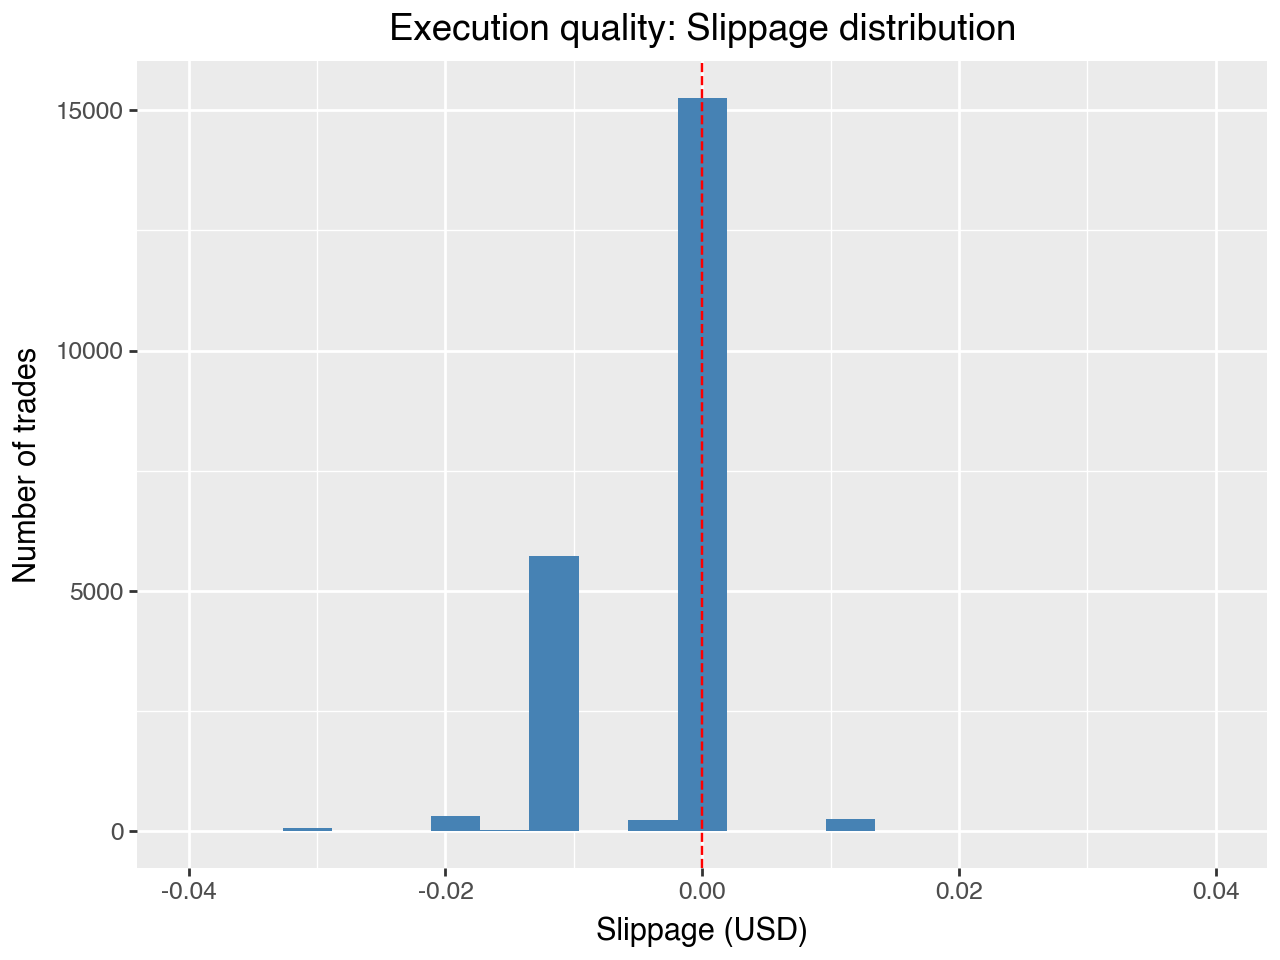

In [92]:
# Plot slippage distribution
(ggplot(trades_matched_us, aes(x="slippage"))
 + geom_histogram(bins=40, fill="steelblue")
 + coord_cartesian(xlim=(-0.04, 0.04))
 + labs(x="Slippage (USD)", y="Number of trades",
        title="Execution quality: Slippage distribution")
 + geom_vline(xintercept=0, linetype="dashed", color="red")
 )

In [37]:
# Cumulative slippage cost
total_slippage_us = trades_matched_us["slippage_value"].sum()
print(f"Cumulative slippage cost: ${total_slippage_us:,.2f}")
print("(Negative = net price improvement)")

Cumulative slippage cost: $-2,008.27
(Negative = net price improvement)


67.4% of the shares are traded at the NBBO while 29.9% of shares traded are executed with price improvement and only 2.7% at a worse price. The net slippage of the US trades is negative which demonstrates a strong execution quality of trades. The biggest price slippage is accounted for by one large trade of 12,600 shares (1.3% of total trading volume).

**Task 1.6: Market Comparison**

Recreation of Task 1.1 to 1.5 with the EU data set. Comparison of the EU results with the US market results.

**Task 1.6.1: Local BBOs**

Documentation of the local best prices (BBOs) for all venues per available timestamp and a report of all local best sizes for the respective prices. 

In [38]:
# Load eu market data
DATA_DIR_EU = "data/data_EU/"

quotes_eu = pd.read_csv(DATA_DIR_EU + "DE0007500001_quotes_incremental.csv",
                        dtype={"trade_id": str})
trades_eu = pd.read_csv(DATA_DIR_EU + "DE0007500001_trades.csv")

# Inspect datastructure quotes_eu
quotes_eu.describe()
quotes_eu.head(2)

# Inspect datastructure trades_eu
trades_eu.describe()
trades_eu.head(2)

,trade_id,trade_timestamp,publication_timestamp,aggressor_side,price,execution_size,market_state,trade_type,venue
0,6269133135937,2023-09-01 07:00:23.834308000,2023-09-01 07:00:23.834308000,ASK,7.108,166,CONTINUOUS_TRADING,LIT,CEUX
1,6269133135938,2023-09-01 07:00:23.848214000,2023-09-01 07:00:23.848214000,ASK,7.114,2,CONTINUOUS_TRADING,LIT,CEUX


In [39]:
# Convert timestamp column into actual timestamp format
quotes_eu["event_timestamp"] = pd.to_datetime(quotes_eu["event_timestamp"])
quotes_eu.dtypes

trades_eu["trade_timestamp"] = pd.to_datetime(trades_eu["trade_timestamp"])
trades_eu.dtypes


trade_id                         object
trade_timestamp          datetime64[ns]
publication_timestamp               str
aggressor_side                      str
price                           float64
execution_size                    int64
market_state                        str
trade_type                          str
venue                               str
dtype: object

In [40]:
# Find the different venues
quotes_eu["venue"].unique()

<StringArray>
['CEUX', 'AQEU', 'TQEX', 'XETR', 'XMIL']
Length: 5, dtype: str

In [41]:
# Filter for continuous trading
quotes_ct_eu = quotes_eu[quotes_eu["market_state"] == "CONTINUOUS_TRADING"]

# Filter for local BBO changes (price & size)
mask_eu = (
    quotes_ct_eu["is_new_best_price"]
    | quotes_ct_eu["is_new_best_size"]
)

# Subset quotes dataframe to the boolean mask
bbo_changes_eu = quotes_ct_eu[mask_eu]
bbo_changes_eu

,side,price,size,order_id,event_timestamp,lob_action,old_price,old_size,old_order_id,order_executed,...,size_ahead,orders_ahead,best_ask_num_orders,best_bid_num_orders,level_num_orders_total,level_size_total,total_ask_orders,total_bid_orders,market_state,venue
0,BID,7.074,1828,1.081350e+18,2023-09-01 07:00:00.023784000,INSERT,NaN,0,NaN,False,...,0,0,0,1,1,1828,0,1,CONTINUOUS_TRADING,CEUX
1,ASK,7.164,1828,1.081350e+18,2023-09-01 07:00:00.023792000,INSERT,NaN,0,NaN,False,...,0,0,1,1,1,1828,1,1,CONTINUOUS_TRADING,CEUX
5,BID,NaN,0,NaN,2023-09-01 07:00:23.824332000,REMOVE,7.074,1828,1.081350e+18,False,...,0,0,1,1,0,0,3,1,CONTINUOUS_TRADING,CEUX
6,ASK,NaN,0,NaN,2023-09-01 07:00:23.824338000,REMOVE,7.164,1828,1.081350e+18,False,...,0,0,1,1,0,0,2,1,CONTINUOUS_TRADING,CEUX
7,BID,7.108,166,1.081350e+18,2023-09-01 07:00:23.829197000,INSERT,NaN,0,NaN,False,...,0,0,1,1,1,166,2,2,CONTINUOUS_TRADING,CEUX
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
432413,BID,NaN,0,NaN,2023-09-01 15:29:55.220045235,REMOVE,7.332,2160,1.693582e+18,False,...,0,0,6,1,0,0,18,5,CONTINUOUS_TRADING,XMIL
432414,BID,NaN,0,NaN,2023-09-01 15:29:55.220052552,REMOVE,7.330,2160,1.693582e+18,False,...,0,0,6,1,0,0,18,4,CONTINUOUS_TRADING,XMIL
432415,BID,NaN,0,NaN,2023-09-01 15:29:55.220099472,REMOVE,7.322,1366,1.693582e+18,False,...,0,0,6,1,0,0,18,3,CONTINUOUS_TRADING,XMIL
432417,BID,7.316,6000,1.693582e+18,2023-09-01 15:29:55.235353890,INSERT,NaN,0,NaN,False,...,0,0,6,1,1,6000,17,4,CONTINUOUS_TRADING,XMIL


In [42]:
# Check the progress
original_eu = len(quotes_eu)
filtered_eu = len(bbo_changes_eu)


print("Original:", original_eu)
print("After BBO filter:", filtered_eu)
print(f"Reduction: {(1 - filtered_eu / original_eu)*100:.2f} percent")

Original: 432454
After BBO filter: 163798
Reduction: 62.12 percent


Filtering for continuous trading data, new best price changes and best size changes leads to a reduction of quotes by 62%. 

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/plotnine/geoms/geom_path.py:100: PlotnineWarning: geom_path: Removed 1 rows containing missing values.


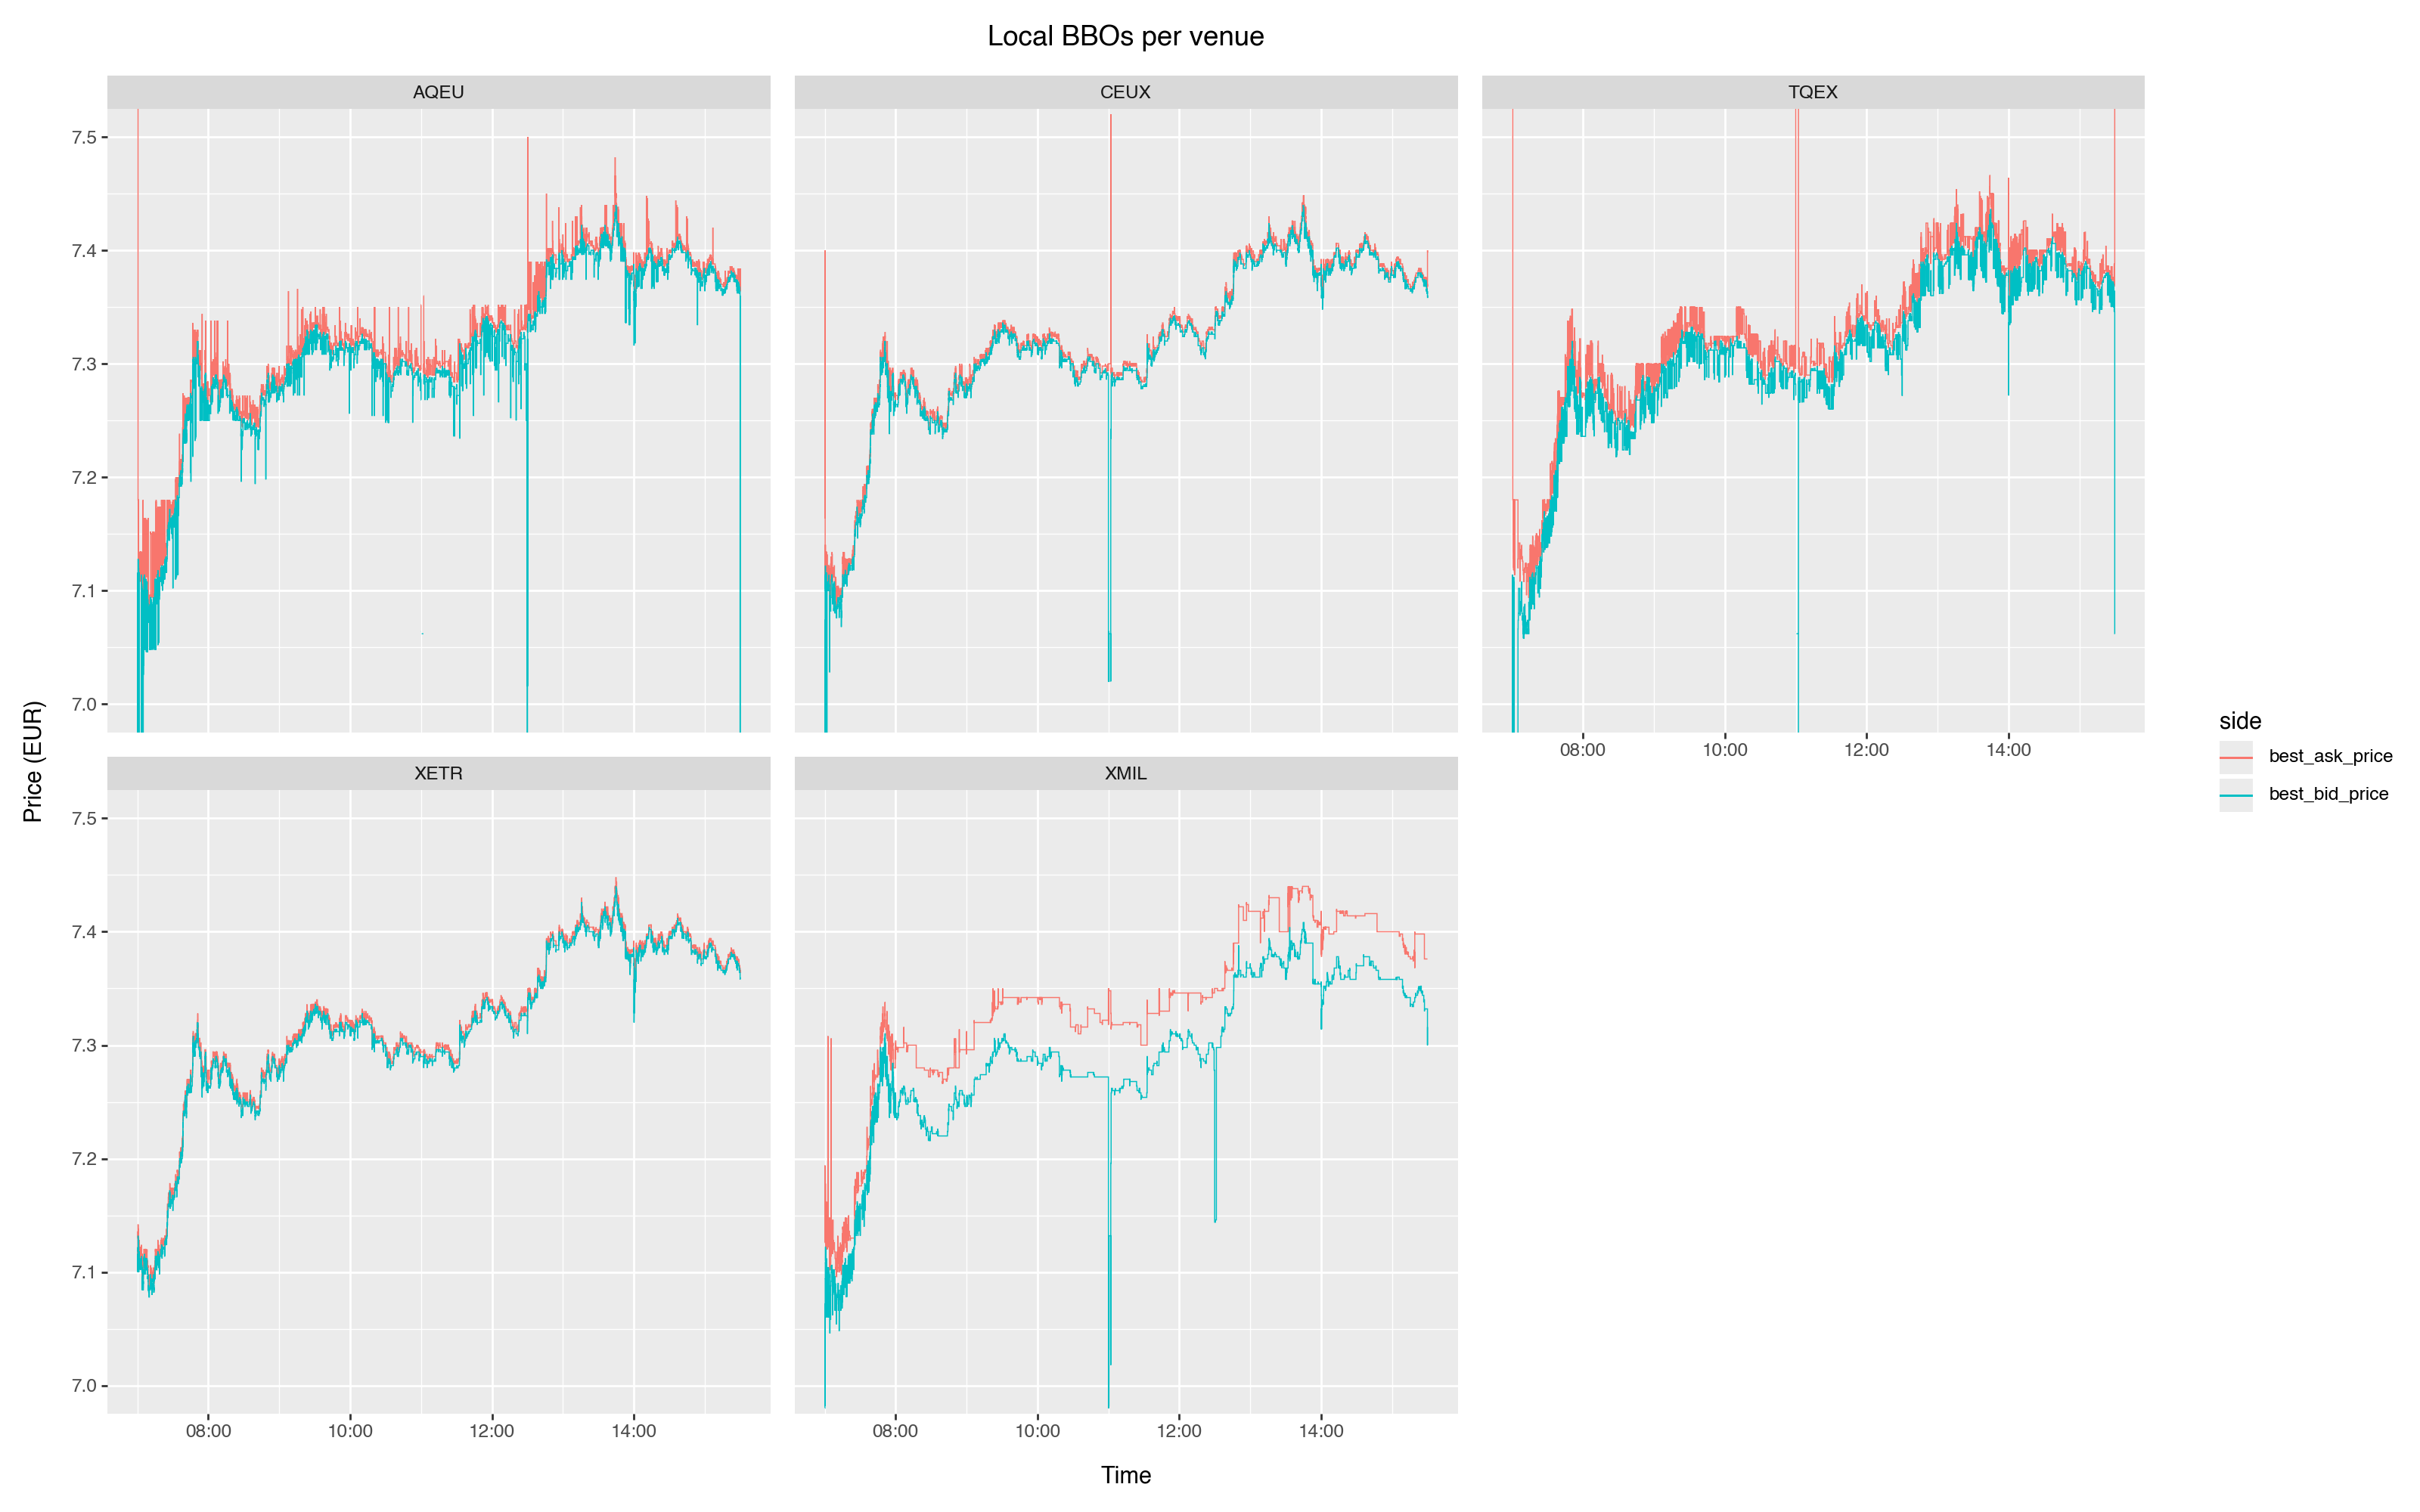

In [43]:
# Select relevant columns for BBO plot
bbo_plot_eu = bbo_changes_eu[[
    "event_timestamp", "venue",
    "best_bid_price", "best_ask_price"
]].copy()

# Reshape to long format for plotting
bbo_long_eu = bbo_plot_eu.melt(
    id_vars=["event_timestamp", "venue"],
    value_vars=["best_bid_price", "best_ask_price"],
    var_name="side",
    value_name="price"
)

# Plot local BBOs per venue
(ggplot(bbo_long_eu, aes(x="event_timestamp", y="price", color="side"))
 + geom_step(size=0.3)
 + facet_wrap("venue", scales="fixed")
 + coord_cartesian(ylim=(7, 7.5))
 + labs(x="Time", y="Price (EUR)", title="Local BBOs per venue")
 + theme(figure_size=(16, 10))
 + scale_x_datetime(labels=date_format("%H:%M"))
 )

The first plot of the EU quotes shows a much clearer picture than the US quote data. The spreads are fairly narrow across most venues, with the exception of XMIL. There are fewer transient price spikes and therefore fewer clearly non-competitive quotes.

In [44]:
# Check for one-sided BBOs
print("Missing bid:", bbo_changes_eu["best_bid_price"].isna().sum())
print("Missing ask:", bbo_changes_eu["best_ask_price"].isna().sum())
print("Zero bid size:", (bbo_changes_eu["best_bid_size"] == 0).sum())
print("Zero ask size:", (bbo_changes_eu["best_ask_size"] == 0).sum())

# Count one-sided BBOs (any condition true)
one_sided_eu = (
    bbo_changes_eu["best_bid_price"].isna()
    | bbo_changes_eu["best_ask_price"].isna()
    | (bbo_changes_eu["best_bid_size"] == 0)
    | (bbo_changes_eu["best_ask_size"] == 0)
)
print("Total one-sided BBOs:", one_sided_eu.sum())

# Remove one-sided BBOs
valid_mask_eu = (
    bbo_changes_eu["best_bid_price"].notna()
    & bbo_changes_eu["best_ask_price"].notna()
    & (bbo_changes_eu["best_bid_size"] > 0)
    & (bbo_changes_eu["best_ask_size"] > 0)
)
bbo_clean_eu = bbo_changes_eu[valid_mask_eu].copy()

# Compute local spread
bbo_clean_eu["spread"] = (
    bbo_clean_eu["best_ask_price"] - bbo_clean_eu["best_bid_price"]
)

# Check spread distribution before winsorisation
print("\nSpread distribution before winsorisation:")
print(bbo_clean_eu["spread"].describe().round(4))
print("Negative spreads:", (bbo_clean_eu["spread"] < 0).sum())

Missing bid: 16
Missing ask: 15
Zero bid size: 16
Zero ask size: 15
Total one-sided BBOs: 24

Spread distribution before winsorisation:
count    163774.0000
mean          0.0226
std           0.1474
min           0.0020
25%           0.0040
50%           0.0060
75%           0.0100
max           3.1000
Name: spread, dtype: float64
Negative spreads: 0


In [45]:
# Test percentiles for winsorisation of the EU quote data
for p in [0.90, 0.95, 0.97, 0.99]:
    print(f"{p:.0%}: €{bbo_clean_eu['spread'].quantile(p):.2f}")

# Winsorize spread at the 99% level
bbo_win_eu = bbo_clean_eu.copy()
bbo_win_eu["spread"] = winsorize(bbo_win_eu["spread"], limits=(0, 0.01))

# Check spread distribution after winsorisation
print("\nSpread distribution after winsorisation:")
print(bbo_win_eu["spread"].describe().round(4))

90%: €0.03
95%: €0.04
97%: €0.05
99%: €0.07

Spread distribution after winsorisation:
count    163774.0000
mean          0.0110
std           0.0125
min           0.0020
25%           0.0040
50%           0.0060
75%           0.0100
max           0.0720
Name: spread, dtype: float64


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:4786: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.


For the US data, we apply one-sided winsorisation at the 95th percentile due to systematically non-competitive quoting on some venues. For the EU data, spread distributions are substantially tighter (median €0.006 vs. $0.05 US). Instead of winsorising the data at the upper 5th percentile, we use 99th percentile, changing less than 1% of observations. The winsorised spread mean decreases to €0.0110 from €0.0226 before, showing the strong effect that a small number of extreme outliers can have on the mean of a distribution.

In [46]:
# Report local best sizes per venue
size_stats_eu = bbo_win_eu.groupby("venue")[
    ["best_bid_size", "best_ask_size"]
].agg(["mean", "median", "min", "max"])

size_stats_eu

best_bid_size                    best_ask_size                   
               mean  median min    max          mean  median min    max
venue                                                                  
AQEU     480.891496   325.0   1   3764    510.142761   325.0   1   9203
CEUX     629.599548   440.0   1  10206    654.285163   440.0   1  10202
TQEX     372.538332   315.0   1   7559    444.243661   317.0   1  11537
XETR    1378.418688  1056.0   1  26201   2267.776045  1331.0   1  46251
XMIL    2647.571459  2160.0   4  19000   2218.471724  2160.0  15  19000

XETR and XMIL report the highest median market depth at the best price with 1056 shares and 2160 shares respectively. The median quoted shares at the local best ask is also greatest for XETR (1331) and XMIL (2160). Similar to the results of the US quote data, we observe the same two distinct dimensions of liquidity. Even though the spreads at venue XMIL are wider than on the other venues, its median depth is far greater.

In [47]:
# Report local best prices and sizes per venue for every available timestamp
bbo_eu = bbo_win_eu[[
    "event_timestamp", "venue",
    "best_bid_price", "best_bid_size",
    "best_ask_price", "best_ask_size"
]].copy()

bbo_eu

,event_timestamp,venue,best_bid_price,best_bid_size,best_ask_price,best_ask_size
1,2023-09-01 07:00:00.023792000,CEUX,7.074,1828,7.164,1828
5,2023-09-01 07:00:23.824332000,CEUX,6.750,10000,7.164,1828
6,2023-09-01 07:00:23.824338000,CEUX,6.750,10000,7.400,10000
7,2023-09-01 07:00:23.829197000,CEUX,7.108,166,7.400,10000
8,2023-09-01 07:00:23.831854000,CEUX,7.108,166,7.132,359
...,...,...,...,...,...,...
432413,2023-09-01 15:29:55.220045235,XMIL,7.330,2160,7.376,2370
432414,2023-09-01 15:29:55.220052552,XMIL,7.322,1366,7.376,2370
432415,2023-09-01 15:29:55.220099472,XMIL,7.300,5000,7.376,2370
432417,2023-09-01 15:29:55.235353890,XMIL,7.316,6000,7.376,2370


**Task 1.6.2: NBBO Reconstruction**

Reconstruction of the global best prices (NBBO) consolidated over all EU venues. The NBBO reports the consolidated depth at the NBBO, number of venues quoting at the NBBO and the per venue distance to the current NBBO.

In [48]:
# Pivot to get one column per venue, forward-fill gaps
bid_wide_eu = bbo_eu.pivot_table(
    index="event_timestamp", columns="venue",
    values="best_bid_price", aggfunc="last"
).ffill()

ask_wide_eu = bbo_eu.pivot_table(
    index="event_timestamp", columns="venue",
    values="best_ask_price", aggfunc="last"
).ffill()

# Compute NBBO
nbbo_eu = pd.DataFrame(index=bid_wide_eu.index)
nbbo_eu["nbbo_bid"] = bid_wide_eu.max(axis=1)
nbbo_eu["nbbo_ask"] = ask_wide_eu.min(axis=1)
nbbo_eu["nbbo_spread"] = nbbo_eu["nbbo_ask"] - nbbo_eu["nbbo_bid"]

print("Negative NBBO spreads:", (nbbo_eu["nbbo_spread"] < 0).sum())
print("Zero spreads (locked):", (nbbo_eu["nbbo_spread"] == 0).sum())
print(nbbo_eu["nbbo_spread"].describe())

Negative NBBO spreads: 1426
Zero spreads (locked): 5066
count    161100.000000
mean          0.004572
std           0.002359
min          -0.012000
25%           0.004000
50%           0.004000
75%           0.006000
max           0.090000
Name: nbbo_spread, dtype: float64


The NBBO shows a significant improvement. Its mean spread of €0.0046 is much tighter than the mean of the accumulated spreads at the separate venues (€0.011). The median NBBO spread (€0.004) is also much narrower than in the US ($0.02). There are 1,426 crossed markets and 5,066 locked (zero-spread) markets, compared to only 19 crossed markets in the US. This most likely stems partly from latency, due to the greater distances between EU venues, and is investigated further in the price-setting section.

In [49]:
bid_wide_eu.head(10)
ask_wide_eu.head(10)

venue,AQEU,CEUX,TQEX,XETR,XMIL
event_timestamp,,,,,
2023-09-01 07:00:00.023792000,NaN,7.164,NaN,NaN,NaN
2023-09-01 07:00:12.541504638,NaN,7.164,NaN,NaN,7.168
2023-09-01 07:00:12.541512864,NaN,7.164,NaN,NaN,7.168
2023-09-01 07:00:12.541523631,NaN,7.164,NaN,NaN,7.194
2023-09-01 07:00:12.541526740,NaN,7.164,NaN,NaN,7.192
2023-09-01 07:00:12.541768811,NaN,7.164,NaN,NaN,7.166
2023-09-01 07:00:12.559374565,NaN,7.164,NaN,NaN,7.166
2023-09-01 07:00:12.559667145,NaN,7.164,NaN,NaN,7.166
2023-09-01 07:00:23.819462822,NaN,7.164,NaN,7.12,7.166


In [50]:
# Pivot sizes the same way
bid_size_wide_eu = bbo_eu.pivot_table(
    index="event_timestamp", columns="venue",
    values="best_bid_size", aggfunc="last"
).ffill()

ask_size_wide_eu = bbo_eu.pivot_table(
    index="event_timestamp", columns="venue",
    values="best_ask_size", aggfunc="last"
).ffill()

# Consolidated depth: sum of sizes where venue price == NBBO price
nbbo_eu["depth_bid"] = bid_size_wide_eu[
    bid_wide_eu.eq(nbbo_eu["nbbo_bid"], axis=0)
].sum(axis=1)

nbbo_eu["depth_ask"] = ask_size_wide_eu[
    ask_wide_eu.eq(nbbo_eu["nbbo_ask"], axis=0)
].sum(axis=1)

nbbo_eu["venues_at_bid"] = (
    bid_wide_eu.eq(nbbo_eu["nbbo_bid"], axis=0).sum(axis=1)
)
nbbo_eu["venues_at_ask"] = (
    ask_wide_eu.eq(nbbo_eu["nbbo_ask"], axis=0).sum(axis=1)
)

cols = ["depth_bid", "depth_ask", "venues_at_bid", "venues_at_ask"]
print(nbbo_eu[cols].describe().round(2))

       depth_bid  depth_ask  venues_at_bid  venues_at_ask
count  161100.00  161100.00      161100.00      161100.00
mean     1684.44    2380.89           2.18           2.16
std      1664.99    3607.52           1.03           1.11
min         1.00       1.00           1.00           1.00
25%       549.00     640.00           1.00           1.00
50%      1212.00    1447.00           2.00           2.00
75%      2349.00    2956.00           3.00           3.00
max     27632.00   48914.00           4.00           5.00


At the European NBBO, consolidated depth averages 1,684 shares on the bid and 2,381 on the ask (median 1,212 and 1,447), with a median of two venues quoting at each side. This is far deeper than the US NBBO (median 174 bid / 200 ask), reflecting the larger displayed sizes on the EU venues.

In [51]:
# Per-venue distance to NBBO (positive = worse than NBBO)
bid_distance_eu = nbbo_eu["nbbo_bid"] - bid_wide_eu.T  # NBBO_bid - venue_bid
ask_distance_eu = ask_wide_eu.T - nbbo_eu["nbbo_ask"]  # venue_ask - NBBO_ask

# Identify which venues quote at the NBBO bid
venues_at_nbbo_bid_eu = bid_wide_eu.eq(nbbo_eu["nbbo_bid"], axis=0)
venues_at_nbbo_ask_eu = ask_wide_eu.eq(nbbo_eu["nbbo_ask"], axis=0)

# Example: check which venues are at NBBO for first 5 timestamps
print(venues_at_nbbo_bid_eu.head(10))

venue                           AQEU   CEUX   TQEX   XETR   XMIL
event_timestamp                                                 
2023-09-01 07:00:00.023792000  False   True  False  False  False
2023-09-01 07:00:12.541504638  False   True  False  False  False
2023-09-01 07:00:12.541512864  False   True  False  False  False
2023-09-01 07:00:12.541523631  False   True  False  False  False
2023-09-01 07:00:12.541526740  False   True  False  False  False
2023-09-01 07:00:12.541768811  False   True  False  False  False
2023-09-01 07:00:12.559374565  False   True  False  False  False
2023-09-01 07:00:12.559667145  False   True  False  False  False
2023-09-01 07:00:23.819462822  False  False  False   True  False
2023-09-01 07:00:23.824332000  False  False  False   True  False


In [52]:
# Share of time each venue quotes at the NBBO bid/ask
pct_at_nbbo_bid_eu = venues_at_nbbo_bid_eu.mean() * 100
pct_at_nbbo_ask_eu = venues_at_nbbo_ask_eu.mean() * 100

print("% of time at NBBO bid:")
print(pct_at_nbbo_bid_eu.sort_values(ascending=False).round(1))
print("\n% of time at NBBO ask:")
print(pct_at_nbbo_ask_eu.sort_values(ascending=False).round(1))

% of time at NBBO bid:
venue
XETR    76.1
CEUX    73.8
AQEU    45.9
TQEX    21.7
XMIL     0.1
dtype: float64

% of time at NBBO ask:
venue
XETR    75.3
CEUX    64.8
AQEU    46.3
TQEX    24.3
XMIL     5.0
dtype: float64


XETR is present at the NBBO most often (76.1% on the bid, 75.3% on the ask), followed by CEUX (73.8% / 64.8%). XMIL, despite leading on depth, quotes at the NBBO only 0.1% of the time on the bid and 5.0% on the ask.

In [53]:
# Average distance per venue to NBBO
print("Bid distance to NBBO (positive = worse):")
print(bid_distance_eu.mean(axis=1).sort_values())
print("\nAsk distance to NBBO (positive = worse):")
print(ask_distance_eu.mean(axis=1).sort_values())

Bid distance to NBBO (positive = worse):
venue
XETR    0.000626
CEUX    0.003323
XMIL    0.023586
AQEU    0.046539
TQEX    0.062277
dtype: float64

Ask distance to NBBO (positive = worse):
venue
XETR    0.000631
CEUX    0.001225
AQEU    0.005191
TQEX    0.010364
XMIL    0.014419
dtype: float64


The per-venue distance to the NBBO mirrors this ranking. XETR sits almost exactly at the NBBO (€0.0006 on both sides), while TQEX and AQEU are farthest on the bid (€0.06 and €0.05). As in the US, this event-weighted measure partly reflects quote staleness for less active venues and is read together with each venue's share of time at the NBBO.

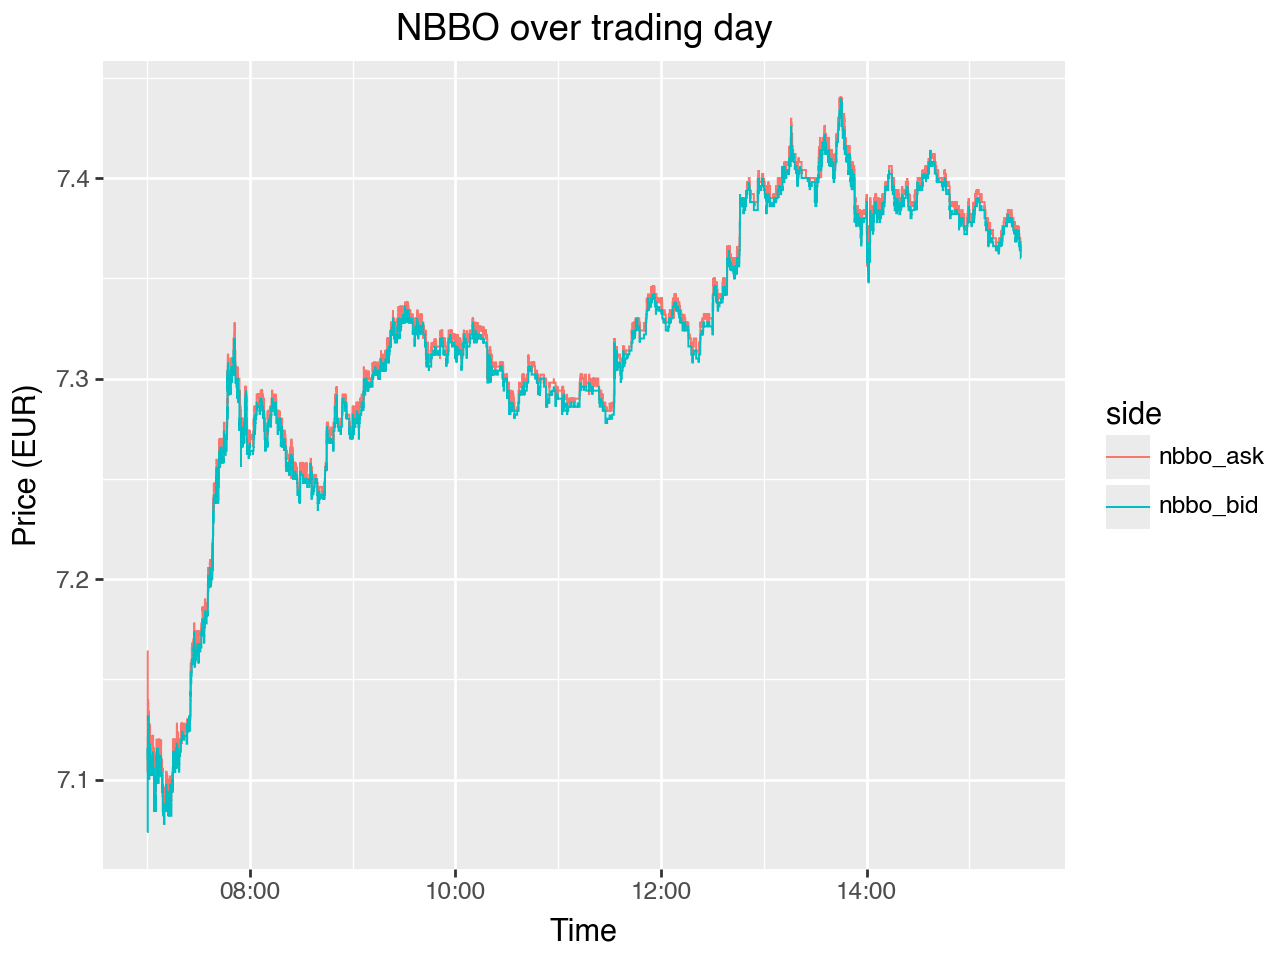

In [54]:
# Plot NBBO
nbbo_plot_eu = nbbo_eu[["nbbo_bid", "nbbo_ask"]].reset_index().melt(
    id_vars="event_timestamp", var_name="side", value_name="price"
)

(ggplot(nbbo_plot_eu, aes(x="event_timestamp", y="price", color="side"))
 + geom_step(size=0.4)
 + labs(x="Time", y="Price (EUR)", title="NBBO over trading day")
 + scale_x_datetime(labels=date_format("%H:%M"))
 )

**Task 1.6.3: Price Setting Mechanics**

Illustration of price setting mechanics across venues and calculation of adjustment times.

In [55]:
# Detect NBBO bid changes
nbbo_eu["bid_changed"] = nbbo_eu["nbbo_bid"] != nbbo_eu["nbbo_bid"].shift(1)
nbbo_eu["ask_changed"] = nbbo_eu["nbbo_ask"] != nbbo_eu["nbbo_ask"].shift(1)

print("NBBO bid changes:", nbbo_eu["bid_changed"].sum())
print("NBBO ask changes:", nbbo_eu["ask_changed"].sum())

NBBO bid changes: 5646
NBBO ask changes: 6967


In [56]:
# For each NBBO bid change, find which venue(s) quote the new best bid
nbbo_bid_changes_eu = nbbo_eu[nbbo_eu["bid_changed"]].copy()

# At each change, check which venues match the new NBBO bid
setter_bid_eu = bid_wide_eu.loc[nbbo_bid_changes_eu.index].eq(
    nbbo_bid_changes_eu["nbbo_bid"], axis=0
)

# Count how often each venue is the price setter
print("Price setter frequency in % (bid):")
print((setter_bid_eu.sum() / setter_bid_eu.sum().sum() * 100).round(1))

Price setter frequency in % (bid):
venue
AQEU    18.5
CEUX    27.8
TQEX     8.9
XETR    44.7
XMIL     0.2
dtype: float64


In [57]:
# Price setter frequency (ask)
nbbo_ask_changes_eu = nbbo_eu[nbbo_eu["ask_changed"]].copy()
setter_ask_eu = ask_wide_eu.loc[nbbo_ask_changes_eu.index].eq(
    nbbo_ask_changes_eu["nbbo_ask"], axis=0
)
print("Price setter frequency in % (ask):")
print((setter_ask_eu.sum() / setter_ask_eu.sum().sum() * 100).round(1))

Price setter frequency in % (ask):
venue
AQEU    18.3
CEUX    24.3
TQEX    11.6
XETR    44.0
XMIL     1.7
dtype: float64


In [58]:
# Compute adjustment time per venue for bid changes
adj_times_bid_eu = {}

for venue in bid_wide_eu.columns:
    times = []
    for ts in nbbo_bid_changes_eu.index:
        new_bid_eu = nbbo_bid_changes_eu.loc[ts, "nbbo_bid"]
        # Skip if venue already at new NBBO
        if bid_wide_eu.loc[ts, venue] == new_bid_eu:
            continue
        # Find next time this venue matches the new NBBO bid
        future = bid_wide_eu.loc[ts:, venue]
        match = future[future == new_bid_eu]
        if len(match) > 0:
            delta = (match.index[0] - ts).total_seconds()
            times.append(delta)
    adj_times_bid_eu[venue] = np.mean(times) if times else np.nan

print("Mean adjustment time to NBBO bid (s):")
print(pd.Series(adj_times_bid_eu).sort_values().round(2))

Mean adjustment time to NBBO bid (s):
XETR      65.44
CEUX      97.97
AQEU     147.13
TQEX     352.81
XMIL    2221.21
dtype: float64


In [59]:
# Compute adjustment time per venue for ask changes
adj_times_ask_eu = {}

for venue in ask_wide_eu.columns:
    times = []
    for ts in nbbo_ask_changes_eu.index:
        new_ask_eu = nbbo_ask_changes_eu.loc[ts, "nbbo_ask"]
        if ask_wide_eu.loc[ts, venue] == new_ask_eu:
            continue
        future = ask_wide_eu.loc[ts:, venue]
        match = future[future == new_ask_eu]
        if len(match) > 0:
            delta = (match.index[0] - ts).total_seconds()
            times.append(delta)
    adj_times_ask_eu[venue] = np.mean(times) if times else np.nan

print("Mean adjustment time to NBBO ask (seconds):")
print(pd.Series(adj_times_ask_eu).sort_values().round(2))

Mean adjustment time to NBBO ask (seconds):
XETR      99.61
CEUX     105.99
AQEU     136.28
TQEX     230.20
XMIL    1634.18
dtype: float64


XETR dominates price setting on both sides of the EU NBBO (44.7% of bid setter instances and 44.0% of ask), followed by CEUX (27.8% and 24.3%). XMIL almost never sets the best price (0.2% bid, 1.7% ask) despite posting the deepest quotes, confirming that depth and price competitiveness are separate dimensions of liquidity. XETR is also the fastest to adjust to a new NBBO (65.4s on the bid, 99.6s on the ask), whereas XMIL is by far the slowest (2,221s and 1,634s), consistent with its rare presence at the NBBO. Compared to the US, where XNAS sets 43.7% and 44.1% and adjusts in 34.9s and 25.0s, the leading EU venue plays the same dominant role but adjusts noticeably slower. This is in line with the geographic dispersion of the EU venues and the much higher number of crossed markets, and with the empirical regularity that the listing (home) market leads price discovery for its security (Hasbrouck, 1995).

**Task 1.6.4: Lee-Ready Classification**

Identification and comparison of the aggressor side of each trade through the Lee and Ready (1991) algorithm with the dataset labels.

In [60]:
# Match each trade to prevailing NBBO using merge_asof
trades_ct_eu = trades_eu[
    trades_eu["market_state"] == "CONTINUOUS_TRADING"
].copy()
trades_ct_eu = trades_ct_eu.sort_values("trade_timestamp")

trades_matched_eu = pd.merge_asof(
    trades_ct_eu,
    nbbo_eu[["nbbo_bid", "nbbo_ask"]].reset_index(),
    left_on="trade_timestamp",
    right_on="event_timestamp",
    direction="backward"
)

# Compute midpoint
trades_matched_eu["midpoint"] = (
    trades_matched_eu["nbbo_bid"] + trades_matched_eu["nbbo_ask"]
) / 2

trades_matched_eu.head(100)

,trade_id,trade_timestamp,publication_timestamp,aggressor_side,price,execution_size,market_state,trade_type,venue,event_timestamp,nbbo_bid,nbbo_ask,midpoint
0,1693551623833662172,2023-09-01 07:00:23.833688568,2023-09-01 07:00:23.833688568,BID,7.104,185,CONTINUOUS_TRADING,LIT,XETR,2023-09-01 07:00:23.833688568,7.114,7.106,7.110
1,6269133135937,2023-09-01 07:00:23.834308000,2023-09-01 07:00:23.834308000,ASK,7.108,166,CONTINUOUS_TRADING,LIT,CEUX,2023-09-01 07:00:23.834308000,7.114,7.106,7.110
2,6269133135938,2023-09-01 07:00:23.848214000,2023-09-01 07:00:23.848214000,ASK,7.114,2,CONTINUOUS_TRADING,LIT,CEUX,2023-09-01 07:00:23.848214000,7.108,7.118,7.113
3,1693551624628880494,2023-09-01 07:00:24.628906176,2023-09-01 07:00:24.628906176,BID,7.110,185,CONTINUOUS_TRADING,LIT,XETR,2023-09-01 07:00:24.628906176,7.102,7.112,7.107
4,6269133135970,2023-09-01 07:00:30.212645000,2023-09-01 07:00:30.212645000,BID,7.114,16,CONTINUOUS_TRADING,LIT,CEUX,2023-09-01 07:00:30.212645000,7.110,7.114,7.112
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,1693551996461585066,2023-09-01 07:06:36.461622314,2023-09-01 07:06:36.461622314,ASK,7.108,370,CONTINUOUS_TRADING,LIT,XETR,2023-09-01 07:06:36.461622314,7.106,7.110,7.108
96,1693551996461585066,2023-09-01 07:06:36.461625523,2023-09-01 07:06:36.461625523,ASK,7.106,319,CONTINUOUS_TRADING,LIT,XETR,2023-09-01 07:06:36.461625523,7.104,7.110,7.107
97,1693552093708083165,2023-09-01 07:08:13.708133662,2023-09-01 07:08:13.708133662,ASK,7.110,319,CONTINUOUS_TRADING,LIT,XETR,2023-09-01 07:08:13.708133662,7.110,7.120,7.115
98,1693552093708083165,2023-09-01 07:08:13.708138343,2023-09-01 07:08:13.708138343,ASK,7.108,1453,CONTINUOUS_TRADING,LIT,XETR,2023-09-01 07:08:13.708138343,7.106,7.108,7.107


In [61]:
# Lee-Ready: Quote Test
trades_matched_eu["lr_side"] = np.where(
    trades_matched_eu["price"] > trades_matched_eu["midpoint"], "BUY",
    np.where(
        trades_matched_eu["price"] < trades_matched_eu["midpoint"], "SELL",
        None  # exactly at midpoint → tick test needed
    )
)

# Tick Test for trades at the midpoint
trades_matched_eu["price_change"] = trades_matched_eu["price"].diff()
trades_matched_eu["tick_direction"] = trades_matched_eu[
    "price_change"
].apply(lambda x: "BUY" if x > 0 else ("SELL" if x < 0 else None))
trades_matched_eu["tick_direction"] = (
    trades_matched_eu["tick_direction"].ffill()
)

# Fill midpoint trades with tick test
at_midpoint_eu = trades_matched_eu["lr_side"].isna()
trades_matched_eu.loc[at_midpoint_eu, "lr_side"] = trades_matched_eu.loc[
    at_midpoint_eu, "tick_direction"
]

print("Lee-Ready classification:")
print(trades_matched_eu["lr_side"].value_counts())
print(f"\nTrades at midpoint (tick test used): {at_midpoint_eu.sum()}")

Lee-Ready classification:
lr_side
SELL    4533
BUY     4320
Name: count, dtype: int64

Trades at midpoint (tick test used): 1587


In [62]:
# Map dataset labels (aggressor's book side) to trade direction
label_map_eu = {"ASK": "SELL", "BID": "BUY"}
trades_matched_eu["aggressor_mapped"] = (
    trades_matched_eu["aggressor_side"].map(label_map_eu)
)

comparable_eu = trades_matched_eu["aggressor_mapped"].notna()
trades_matched_eu["match"] = (
    trades_matched_eu["lr_side"] == trades_matched_eu["aggressor_mapped"]
)
agree_rate_eu = trades_matched_eu.loc[comparable_eu, "match"].mean()
print(f"Agreement rate: {agree_rate_eu:.1%}")
print(f"UNKNOWN trades excluded: {(~comparable_eu).sum()}")

Agreement rate: 83.3%
UNKNOWN trades excluded: 343


In [63]:
# Number of trades per aggressor side
print("Trades per side (Lee-Ready):")
print(trades_matched_eu.groupby("lr_side")["execution_size"].agg(
    trades="count", total_shares="sum"
))

Trades per side (Lee-Ready):
         trades  total_shares
lr_side                      
BUY        4320       2569446
SELL       4533       2126087


4,320 trades are classified as buys and 4,533 as sells by the Lee-Ready algorithm. 1,587 trades (17.9%) fell at the midpoint and required the tick test, a share very similar to the US (18.3%). The agreement rate with the dataset labels is 83.3% (excluding unknown trades), somewhat lower than the 88.4% achieved on the US data. Since the midpoint share is comparable, the lower agreement is consistent with a noisier EU NBBO. The far higher number of crossed and locked markets and the slower quote adjustment make the prevailing quote a less reliable benchmark at the moment of the trade.

**Task 1.6.5: Execution Quality**

Comparison of the trade price with the prevailing NBBO and identification of the cumulative slippage cost.

In [64]:
# Compute slippage: trade price vs NBBO
# For buys: slippage = price - nbbo_ask (positive = overpaid)
# For sells: slippage = nbbo_bid - price (positive = undersold)
trades_matched_eu["slippage"] = np.where(
    trades_matched_eu["lr_side"] == "BUY",
    trades_matched_eu["price"] - trades_matched_eu["nbbo_ask"],
    trades_matched_eu["nbbo_bid"] - trades_matched_eu["price"]
)

print(trades_matched_eu["slippage"].describe())
n_zero_eu = (trades_matched_eu["slippage"] == 0).sum()
n_worse_eu = (trades_matched_eu["slippage"] > 0).sum()
n_better_eu = (trades_matched_eu["slippage"] < 0).sum()
print(f"\nTrades at best (slippage == 0): {n_zero_eu}")
print(f"Trades worse than NBBO: {n_worse_eu}")
print(f"Trades better than NBBO: {n_better_eu}")

count    8853.000000
mean        0.000090
std         0.002055
min        -0.006000
25%         0.000000
50%         0.000000
75%         0.000000
max         0.032000
Name: slippage, dtype: float64

Trades at best (slippage == 0): 5716
Trades worse than NBBO: 1284
Trades better than NBBO: 1853


In [65]:
# Determine the tick size: smallest increment between distinct quoted prices
ask_eu = trades_matched_eu["nbbo_ask"].dropna()
tick_eu = np.diff(np.sort(ask_eu.unique())).min()
print(f"Smallest quote increment (tick): €{tick_eu:.4f}")

Smallest quote increment (tick): €0.0020


In [100]:
# Define slippage buckets in ticks
def bucket_slippage_eu(s):
    s_ticks = abs(s)/tick_eu  # convert to ticks
    if s == 0:
        return "at best"
    elif s < 0:  # price improvement
        if s_ticks <= 0.5:
            return "improved up to 0.5 ticks"
        elif s_ticks <= 1:
            return "improved up to 1 tick"
        elif s_ticks <= 5:
            return "improved up to 5 ticks"
        else:
            return "improved more than 5 ticks"
    else:  # slippage
        if s_ticks <= 0.5:
            return "worsened up to 0.5 ticks"
        elif s_ticks <= 1:
            return "worsened up to 1 tick"
        elif s_ticks <= 5:
            return "worsened up to 5 ticks"
        else:
            return "worsened more than 5 ticks"

trades_matched_eu["slippage_bucket_ticks"] = trades_matched_eu["slippage"].apply(
    bucket_slippage_eu
)

# Calculate the slippage value (EUR cost) per trade
trades_matched_eu["slippage_value"] = (
    trades_matched_eu["slippage"] * trades_matched_eu["execution_size"]
)

# Build execution quality table in ticks
eq_table_eu = trades_matched_eu.groupby("slippage_bucket_ticks").agg(
    trades=("execution_size", "count"),
    shares=("execution_size", "sum"),
    slippage_cost=("slippage_value", "sum")
).round(2)

eq_table_eu["share_pct"] = (
    eq_table_eu["shares"] / eq_table_eu["shares"].sum() * 100
).round(2)

eq_table_eu = eq_table_eu.reindex(
    [b for b in order_ticks if b in eq_table_eu.index]
)
print("Execution quality buckets (ticks):")
print(eq_table_eu)

# Define slippage buckets in cents
def bucket_slippage_eu_cent(s):
    s_cents = abs(s) * 100  # distance in cents
    if s == 0:
        return "at best"
    elif s < 0:
        if s_cents <= 0.5:
            return "improved up to 0.5 cent"
        elif s_cents <= 1:
            return "improved up to 1 cent"
        elif s_cents <= 5:
            return "improved up to 5 cent"
        else:
            return "improved more than 5 cent"
    else:
        if s_cents <= 0.5:
            return "worsened up to 0.5 cent"
        elif s_cents <= 1:
            return "worsened up to 1 cent"
        elif s_cents <= 5:
            return "worsened up to 5 cent"
        else:
            return "worsened more than 5 cent"

# Assign cent-based slippage buckets
trades_matched_eu["slippage_bucket_cent"] = (
    trades_matched_eu["slippage"].apply(bucket_slippage_eu_cent)
)

# Build execution quality table in cents
eq_table_eu_cent = trades_matched_eu.groupby("slippage_bucket_cent").agg(
    trades=("execution_size", "count"),
    shares=("execution_size", "sum"),
    slippage_cost=("slippage_value", "sum")
).round(2)

order_cent = [
    "improved more than 5 cent", "improved up to 5 cent", 
    "improved up to 1 cent", "improved up to 0.5 cent", "at best",
    "worsened up to 0.5 cent", "worsened up to 1 cent",
    "worsened up to 5 cent", "worsened more than 5 cent",
]

eq_table_eu_cent = eq_table_eu_cent.reindex(
    [b for b in order_cent if b in eq_table_eu_cent.index]
)

eq_table_eu_cent["share_pct"] = (
    eq_table_eu_cent["shares"] / eq_table_eu_cent["shares"].sum() * 100
).round(2)

print("\nExecution quality buckets (Cent):")
print(eq_table_eu_cent)

Execution quality buckets (ticks):
                            trades   shares  slippage_cost  share_pct
slippage_bucket_ticks                                                
improved up to 5 ticks         357   160675        -374.28       3.42
improved up to 1 tick         1469   739384       -1464.00      15.75
improved up to 0.5 ticks        27    14547         -14.55       0.31
at best                       5716  3037072           0.00      64.68
worsened up to 0.5 ticks         6     3832           3.83       0.08
worsened up to 1 tick          603   309443         613.76       6.59
worsened up to 5 ticks         623   373743        1684.70       7.96
worsened more than 5 ticks      52    56837         906.19       1.21

Execution quality buckets (Cent):
                         trades   shares  slippage_cost  share_pct
slippage_bucket_cent                                              
improved up to 1 cent         3      237          -1.42       0.01
improved up to 0.5 cent    18

The EU buckets are reported in both units. In cents the distance is the absolute monetary distance to the NBBO, while in ticks it is normalised by the local tick of €0.002. Because the EU tick differs from one cent, the two groupings are not identical, unlike in the US where one cent equals one tick. The tick view is what makes execution quality directly comparable across the two markets.

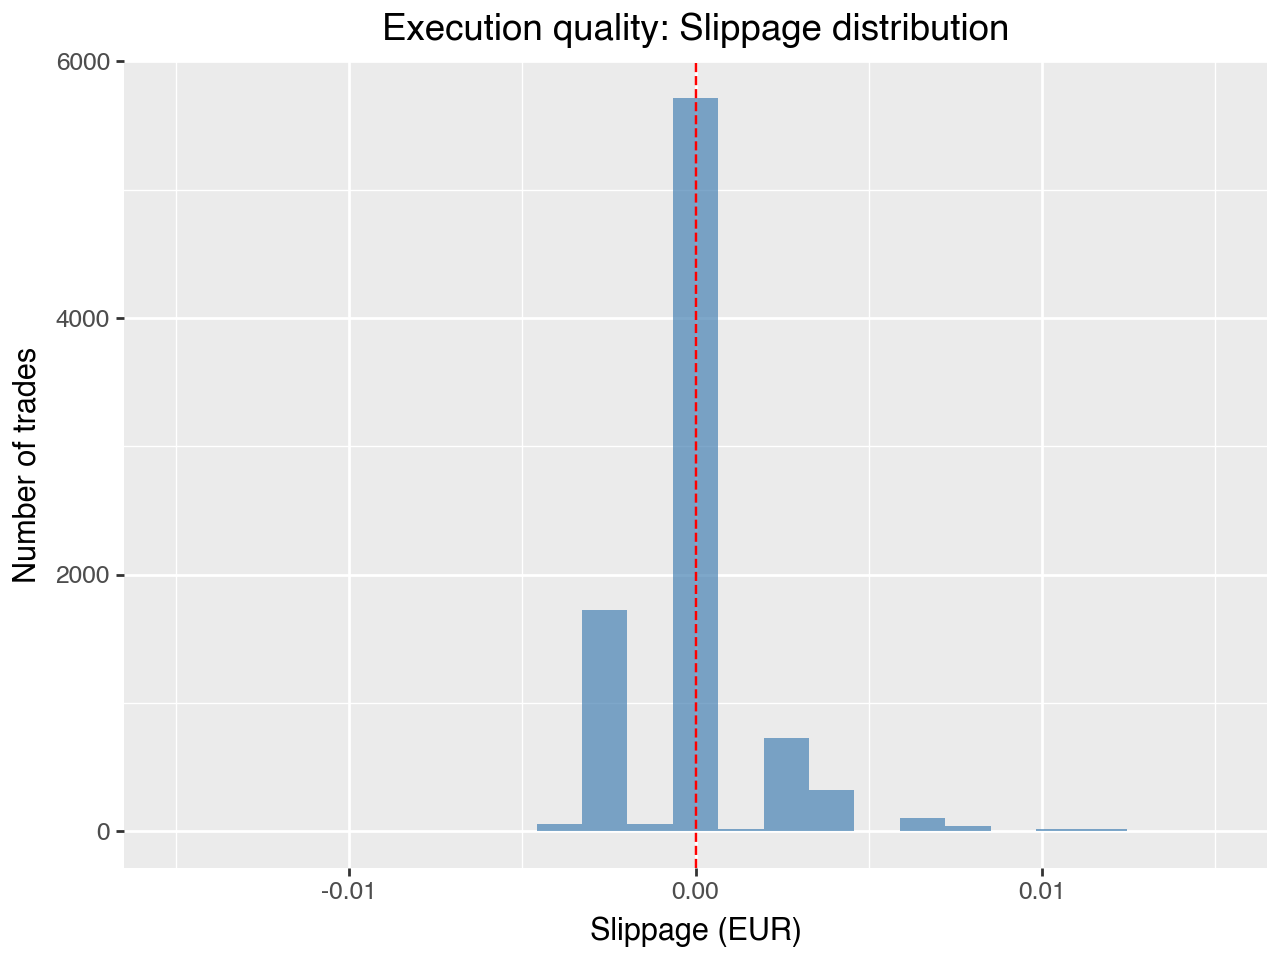

In [91]:
# Plot slippage distribution
(ggplot(trades_matched_eu, aes(x="slippage"))
 + geom_histogram(bins=30, fill="steelblue", alpha=0.7)
 + coord_cartesian(xlim=(-0.015, 0.015))
 + labs(x="Slippage (EUR)", y="Number of trades",
        title="Execution quality: Slippage distribution")
 + geom_vline(xintercept=0, linetype="dashed", color="red")
 )

In [75]:
# Cumulative slippage cost
total_slippage_eu = (trades_matched_eu["slippage_value"]).sum()
print(f"Cumulative slippage cost: €{total_slippage_eu:,.2f}")
print("(Negative = net price improvement)")

Cumulative slippage cost: €1,355.65
(Negative = net price improvement)


64.7% of the shares are traded at the NBBO, while 19.5% are executed with price improvement and 15.8% at a worse price. The cumulative slippage is positive at €1,355.65, meaning that on aggregate trades executed slightly worse than the prevailing NBBO. This contrasts with the US, where the cumulative slippage was negative (net price improvement: $2,008), so execution quality on the EU venues is weaker than in the US.

**Discussion**

Both securities trade in fragmented markets, across eleven venues in the US and five in the EU, and in both cases consolidation into a single best bid and offer materially improves the visible market. The mean spread tightens from $0.30 across the individual US venues to $0.02 at the US NBBO, and from €0.011 to €0.0046 at the EU NBBO. Consolidated depth is also far greater than any single venue provides, with a median of two venues quoting at each side of the NBBO in both markets.

In both markets a single venue dominates price formation. XNAS sets the US NBBO 43.7% of the time on the bid and 44.1% on the ask, and XETR sets the EU NBBO 44.7% and 44.0%. These are the listing venues for the respective securities, which is consistent with the empirical regularity that the home market leads price discovery (Hasbrouck, 1995). The same venues are present at the NBBO most often, XNAS over 82% of the time and XETR around 76%.

The central structural difference between the two markets is infrastructure. US venues are co-located in New Jersey, whereas the EU venues are geographically dispersed across Frankfurt, London and Milan. This dispersion shows up clearly in two results. First, crossed markets are far more frequent in the EU, with 1,426 instances against only 19 in the US, because asynchronous quote updates across distant venues create transient dislocations that a consolidated NBBO without latency adjustment records as crossed states. Second, venues adjust to a new NBBO much more slowly in the EU, where the fastest venue XETR takes 65 seconds on the bid and 100 on the ask, compared with 35 and 25 seconds for XNAS in the US.

The Lee-Ready algorithm reproduces the dataset aggressor labels well in both markets, with an agreement rate of 88.4% in the US and 83.3% in the EU, both close to the roughly 85% reported in Odders-White (2000). The somewhat lower EU figure is consistent with the noisier EU NBBO, since the higher number of crossed and locked markets makes the prevailing quote a less reliable benchmark at the moment of the trade.

Expressed in ticks to make the two markets comparable, execution quality is clearly stronger in the US. The cumulative slippage is negative in the US, a net price improvement of $2,008, and positive in the EU, a net cost of €1,356. In both markets the majority of share volume executes exactly at the NBBO, 67.4% in the US and 64.7% in the EU, but the US shows far more price improvement (29.9% versus 19.5%) and far less execution at worse prices (2.7% versus 15.8%).

Taken together, the two markets share the same broad structure, fragmented trading consolidated into an NBBO that is dominated by the listing venue, but they differ sharply in the cost of geographic dispersion, which is visible in crossed markets, adjustment speed, classification accuracy and execution quality. The accuracy and especially the comparability of these results could be improved further by adjusting timestamps for the physical location of the venues, which would remove part of the crossed-market artefacts in the EU.